# Multi-Objective Bayesian Optimization (MOBO) — v3
## Ablation Experiment: 2 Inputs × 3 Objectives
Expected Hypervolume Improvement — replicate-informed noise

**v3 changes vs v2** (data still loaded from `../data/ablation_data.xlsx`):
1. **Replicate variance enters the GP**: each objective's `SingleTaskGP` receives
   `train_Yvar = s²/n` (variance of the condition mean, computed from the replicate
   scatter), making observation noise heteroscedastic across conditions instead of a
   single learned value.
2. **Predictive intervals include measurement noise**: comparisons against individual
   replicates use a 95% prediction interval (latent variance + pooled replicate
   variance s̄²), not just the latent-mean CI.

Because the noise model differs, recommendations and hypervolume trajectories
intentionally differ from v1/v2 — `mobo_analysis.ipynb` (v1) and
`mobo_analysis_v2.ipynb` remain the record of the numbers actually sent to UIC.

**Campaign status (Sep 2026):** two real BO iterations are complete (Section 10):
iteration 1 at X1 = 19.6 / X2 = 2.0 (Jul 2026, v1 proposal) and iteration 2 at
X1 = 17.4 / X2 = 1.0 (Aug 2026, proposal from this notebook). Section 10 proposes
iteration 3. Sections 1–9 always use the **initial DOE only** — spreadsheet rows
belonging to campaign iterations are tagged in Section 1 and held out — so the
Jul 10, 2026 recommendation is reproduced on every run regardless of how many
campaign rows have been appended.


## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ── Core ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import gpytorch

# ── BoTorch ──────────────────────────────────────────────────────────────────
from botorch.models import ModelListGP, SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogExpectedHypervolumeImprovement
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cpu')
DTYPE  = torch.double

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__} | BoTorch {__import__('botorch').__version__}")

PyTorch 2.7.1+cu118 | GPyTorch 1.14 | BoTorch 0.14.0


## 1. Data Preparation

Replicate data is read from **`ablation_data.xlsx`** (one row per measurement).
Columns are matched by keyword so cosmetic header changes don't break loading:

| Spreadsheet column | Variable |
|---|---|
| Carbon black wt% | X1 |
| Fe-rich regolith wt% | X2 |
| Linear ablative rate (µm/s) | Y1 |
| Backside temp. (°C) | Y2 |
| Density (g/cm³) | Y3 |

We use the **per-condition means** across replicates as the observed objective value
for each unique (X1, X2) condition. v3 additionally computes each condition's
**replicate variance s²**: s²/n enters the GP as known observation noise
(`train_Yvar`), and the pooled s̄² builds predictive intervals for new replicate
measurements.


In [2]:
# ── Load replicate data from Excel ───────────────────────────────────────────
DATA_FILE = '../data/ablation_data.xlsx'

# BO campaign samples present in the spreadsheet: iteration → [(X1, X2), ...].
# Every other row is the initial DOE (iteration 0). Sections 1–9 train on the
# initial DOE only, so the Jul 10, 2026 recommendation is reproduced on every run;
# Section 10 then adds the campaign iterations one at a time. Extend this dict
# whenever a new iteration's replicates are appended to the spreadsheet.
ITERATION_SAMPLES = {
    1: [(19.6, 2.0)],   # proposed Jul 10, 2026 · tested Jul 20, 2026
    2: [(17.4, 1.0)],   # proposed Aug 12, 2026 · tested Aug 26, 2026
}

def iteration_of(x1, x2):
    """Campaign iteration a condition belongs to (0 = initial DOE)."""
    for it, conds in ITERATION_SAMPLES.items():
        if any(np.isclose(x1, a) and np.isclose(x2, b) for a, b in conds):
            return it
    return 0

def find_col(columns, keyword):
    """Return the unique column whose name contains `keyword` (case-insensitive)."""
    hits = [c for c in columns if keyword.lower() in str(c).lower()]
    assert len(hits) == 1, f"Expected exactly one column matching '{keyword}', found: {hits}"
    return hits[0]

df_xlsx = pd.read_excel(DATA_FILE)
col_map = {
    find_col(df_xlsx.columns, 'carbon black'): 'X1',
    find_col(df_xlsx.columns, 'regolith'):     'X2',
    find_col(df_xlsx.columns, 'ablative'):     'Y1',
    find_col(df_xlsx.columns, 'backside'):     'Y2',
    find_col(df_xlsx.columns, 'density'):      'Y3',
}
df_full = df_xlsx.rename(columns=col_map)[['X1', 'X2', 'Y1', 'Y2', 'Y3']].astype(float)
df_full.insert(0, 'Iteration', [iteration_of(r.X1, r.X2) for r in df_full.itertuples()])
print(f"Loaded {len(df_full)} measurements from {DATA_FILE}")
print(f"Rows per campaign iteration (0 = initial DOE): {df_full.groupby('Iteration').size().to_dict()}")

# Initial DOE (iteration 0) — the training set for Sections 1–9
df = df_full[df_full.Iteration == 0].drop(columns='Iteration').reset_index(drop=True)
rep_counts = df.groupby(['X1', 'X2']).size()
print(f"Initial DOE: {len(df)} measurements | {len(rep_counts)} conditions | "
      f"replicates per condition: {sorted(rep_counts.unique())}")

# ── Per-condition statistics (v3) ────────────────────────────────────────────
NOISE_FLOOR = 1e-6   # variance floor (e.g. Y3 replicates are identical → s² = 0)

def condition_stats(df_rep):
    """Per-condition means, replicate variances s² (ddof=1), the GP observation
    noise s²/n (variance of the condition mean, floored) and the pooled replicate
    variance s̄² per objective — all from a replicate-level DataFrame."""
    g     = df_rep.groupby(['X1', 'X2'])[['Y1', 'Y2', 'Y3']]
    means = g.mean().reset_index()
    var   = g.var().reset_index()
    n     = df_rep.groupby(['X1', 'X2']).size().values
    Yvar  = np.maximum(var[['Y1', 'Y2', 'Y3']].values / n[:, None], NOISE_FLOOR)
    s2    = np.maximum(var[['Y1', 'Y2', 'Y3']].values.mean(axis=0), NOISE_FLOOR)
    return means, var, Yvar, s2

df_mean, df_var, Yvar_mean_np, s2_rep_np = condition_stats(df)

print(f"\nTraining set: {df_mean.shape[0]} conditions")
print(df_mean.to_string(index=False, float_format='{:.4f}'.format))
print("\nPer-condition replicate variance s²:")
print(df_var.to_string(index=False, float_format='{:.4f}'.format))
print(f"\nPooled replicate variance s̄² per objective: {s2_rep_np.round(4)}")
print(f"GP observation noise = s²/n (variance of the condition mean), floored at {NOISE_FLOOR:g}")
display(df_mean)


Loaded 45 measurements from ../data/ablation_data.xlsx
Rows per campaign iteration (0 = initial DOE): {0: 39, 1: 3, 2: 3}
Initial DOE: 39 measurements | 13 conditions | replicates per condition: [np.int64(3)]

Training set: 13 conditions
     X1     X2      Y1       Y2     Y3
 5.0000 1.0000 18.5433 219.0000 1.1350
 5.0000 2.0000 15.4567 214.6667 1.1440
 5.0000 3.0000 11.4500 207.0000 1.1530
 5.0000 4.0000 11.0433 207.3333 1.1630
 5.0000 5.0000 10.7200 204.0000 1.1730
10.0000 3.0000  7.0267 207.3333 1.1770
12.5000 1.0000  7.0833 214.3333 1.1700
12.5000 3.0000  6.8100 196.6667 1.1900
12.5000 5.0000  6.7867 196.0000 1.2110
15.0000 3.0000  6.6400 192.0000 1.2020
20.0000 1.0000  6.1733 184.3333 1.2070
20.0000 3.0000  6.0733 169.3333 1.2290
20.0000 5.0000  6.0633 168.3333 1.2510

Per-condition replicate variance s²:
     X1     X2     Y1       Y2     Y3
 5.0000 1.0000 0.6142  49.0000 0.0000
 5.0000 2.0000 0.6120  24.3333 0.0000
 5.0000 3.0000 0.4179 468.0000 0.0000
 5.0000 4.0000 0.5392  37.

,X1,X2,Y1,Y2,Y3
0,5.0,1.0,18.543333,219.000000,1.135
1,5.0,2.0,15.456667,214.666667,1.144
2,5.0,3.0,11.450000,207.000000,1.153
3,5.0,4.0,11.043333,207.333333,1.163
4,5.0,5.0,10.720000,204.000000,1.173
5,10.0,3.0,7.026667,207.333333,1.177
6,12.5,1.0,7.083333,214.333333,1.170
7,12.5,3.0,6.810000,196.666667,1.190
8,12.5,5.0,6.786667,196.000000,1.211
9,15.0,3.0,6.640000,192.000000,1.202


In [3]:
# ── Scale inputs to [0, 1] ──────────────────────────────────────────────────
X_bounds_orig = np.array([[5.0, 1.0], [20.0, 5.0]])   # [lb, ub] per dim

scaler_X = MinMaxScaler()
scaler_X.fit(X_bounds_orig)

X_np   = df_mean[['X1','X2']].values
Y_np   = df_mean[['Y1','Y2','Y3']].values
X_01   = scaler_X.transform(X_np)

X_train = torch.tensor(X_01, dtype=DTYPE)
Y_train = torch.tensor(Y_np, dtype=DTYPE)     # minimization objectives
Y_neg   = -Y_train                             # negate for BoTorch (maximization convention)
Yvar_train = torch.tensor(Yvar_mean_np, dtype=DTYPE)   # v3: per-point noise variance (unchanged by negation)

# Design-space bounds in [0,1]
bounds  = torch.stack([torch.zeros(2, dtype=DTYPE), torch.ones(2, dtype=DTYPE)])

# Reference point: slightly worse than the nadir in the NEGATED (maximization) space
Y_range  = Y_neg.max(0).values - Y_neg.min(0).values
ref_point = Y_neg.min(0).values - 0.10 * Y_range

print(f"X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"Reference point (negated space): {ref_point.numpy().round(3)}")
print(f"  → corresponds to nadir Y+10% slack: Y1>{-ref_point[0].item():.2f}, Y2>{-ref_point[1].item():.2f}, Y3>{-ref_point[2].item():.4f}")

X_train: torch.Size([13, 2])  Y_train: torch.Size([13, 3])
Reference point (negated space): [ -19.791 -224.067   -1.263]
  → corresponds to nadir Y+10% slack: Y1>19.79, Y2>224.07, Y3>1.2626


## 2. Surrogate Models: Fixed-Noise GPs per Objective (v3)

We use **BoTorch's `SingleTaskGP` with `train_Yvar`** for each objective, bundled
into a `ModelListGP`.

Instead of learning one homoscedastic noise level per objective, each training point
supplies its **known observation-noise variance**: the mean of *n* replicates has
variance s²/n, computed directly from the replicate scatter in the spreadsheet.
Conditions with noisy replicates (notably backside temperature) are trusted less than
quiet ones, and predictive uncertainty reflects the real measurement noise.


In [4]:
def build_and_fit_models(X: torch.Tensor, Y_neg: torch.Tensor, Yvar: torch.Tensor) -> ModelListGP:
    """One fixed-noise SingleTaskGP per objective (negated for maximization).

    Yvar holds the known observation-noise variance of each training point (the
    replicate variance of the condition mean, s²/n) — heteroscedastic across
    conditions instead of a single learned noise level."""
    models = []
    for k in range(Y_neg.shape[1]):
        m = SingleTaskGP(
            X, Y_neg[:, k:k+1],
            train_Yvar=Yvar[:, k:k+1],
            outcome_transform=Standardize(m=1)
        )
        models.append(m)
    model_list = ModelListGP(*models)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(model_list.likelihood, model_list)
    fit_gpytorch_mll(mll)
    return model_list


# Fit on initial 13-condition dataset
model = build_and_fit_models(X_train, Y_neg, Yvar_train)
model.eval()

# Print learned kernel hyperparameters
obj_names = ['Y1 (Ablation)', 'Y2 (Temp)', 'Y3 (Density)']
print("Learned GP Hyperparameters (initial fit)")
print("=" * 55)
for k, (m, name) in enumerate(zip(model.models, obj_names)):
    ls = m.covar_module.lengthscale.detach().numpy().flatten()
    nv = m.likelihood.noise.detach().numpy().ravel()
    print(f"  {name}")
    print(f"    lengthscale = {ls}")
    print(f"    fixed noise (standardised): mean {nv.mean():.3g}, min {nv.min():.3g}, max {nv.max():.3g}")


Learned GP Hyperparameters (initial fit)
  Y1 (Ablation)
    lengthscale = [0.34235357 0.42672125]
    fixed noise (standardised): mean 0.00898, min 0.00157, max 0.0151
  Y2 (Temp)
    lengthscale = [0.5197167  1.02836496]
    fixed noise (standardised): mean 0.156, min 0.00291, max 0.753
  Y3 (Density)
    lengthscale = [1.25384447 1.85949093]
    fixed noise (standardised): mean 0.000864, min 0.000864, max 0.000864


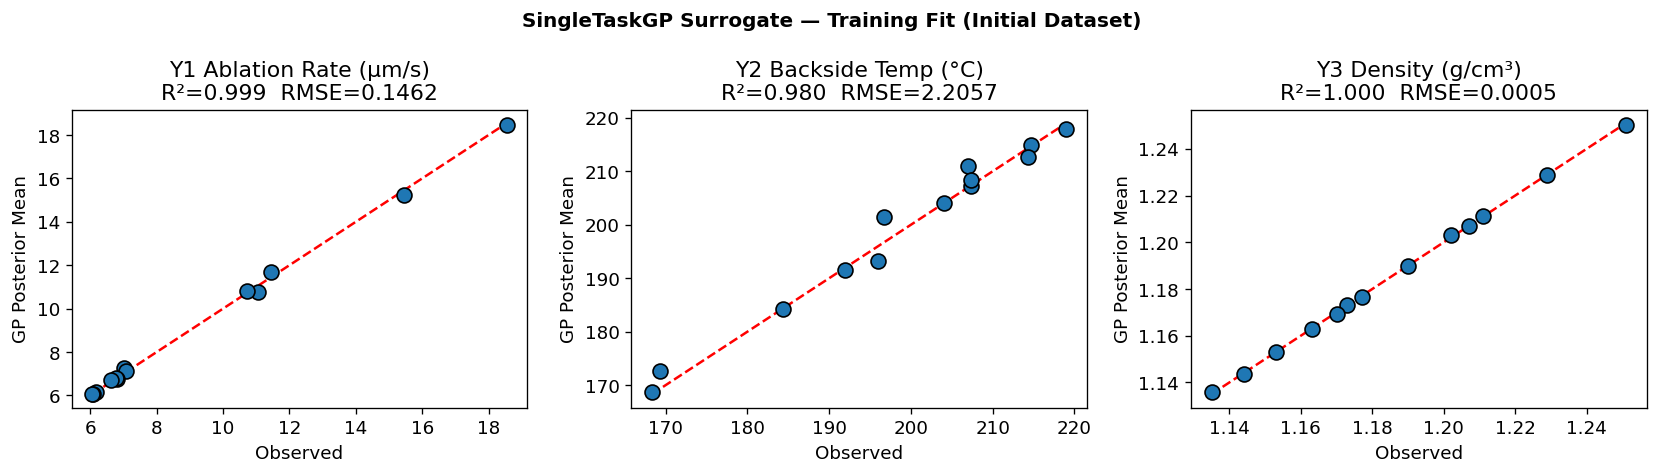

In [5]:
# GP posterior mean on training data vs. actual
with torch.no_grad():
    post = model.posterior(X_train)
    mu_neg = post.mean.numpy()        # (N, 3) in negated space
    mu_orig = -mu_neg                 # back to original scale

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, (ax, name) in enumerate(zip(axes, ['Y1 Ablation Rate (µm/s)', 'Y2 Backside Temp (°C)', 'Y3 Density (g/cm³)'])):
    y_true = Y_np[:, k]
    y_pred = mu_orig[:, k]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.scatter(y_true, y_pred, s=80, edgecolors='k', zorder=3)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel('Observed'); ax.set_ylabel('GP Posterior Mean')
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.4f}')
plt.suptitle('SingleTaskGP Surrogate — Training Fit (Initial Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Pareto Front & Hypervolume (Initial Data)

The **Pareto front** consists of all solutions that are not dominated by any other solution.  
A solution $\mathbf{y}^{(i)}$ **dominates** $\mathbf{y}^{(j)}$ if $y_k^{(i)} \le y_k^{(j)}$ for all $k$, and strictly less for at least one $k$.

The **hypervolume indicator** $\mathcal{H}(\mathcal{P}, \mathbf{r})$ measures the volume of the objective space dominated by the Pareto set $\mathcal{P}$ and bounded by reference point $\mathbf{r}$. It is used as the optimization progress metric.

In [6]:
# Pareto front of initial dataset (in NEGATED space for BoTorch)
pareto_mask_init = is_non_dominated(Y_neg)
Y_pareto_neg  = Y_neg[pareto_mask_init]
Y_pareto_orig = Y_np[pareto_mask_init.numpy()]
X_pareto      = X_np[pareto_mask_init.numpy()]

hv_calculator = Hypervolume(ref_point=ref_point)
hv_init = hv_calculator.compute(Y_neg[pareto_mask_init])

print(f"Initial Pareto front: {pareto_mask_init.sum().item()} / {len(Y_np)} conditions")
print(f"Initial Hypervolume : {hv_init:.4f}")
print()
print("Pareto-optimal conditions (original scale):")
pf_df = pd.DataFrame(
    np.hstack([X_pareto, Y_pareto_orig]),
    columns=['X1', 'X2', 'Y1 (µm/s)', 'Y2 (°C)', 'Y3 (g/cm³)']
)
print(pf_df.to_string(index=False, float_format='{:.3f}'.format))

Initial Pareto front: 12 / 13 conditions
Initial Hypervolume : 51.1684

Pareto-optimal conditions (original scale):
    X1    X2  Y1 (µm/s)  Y2 (°C)  Y3 (g/cm³)
 5.000 1.000     18.543  219.000       1.135
 5.000 2.000     15.457  214.667       1.144
 5.000 3.000     11.450  207.000       1.153
 5.000 4.000     11.043  207.333       1.163
 5.000 5.000     10.720  204.000       1.173
10.000 3.000      7.027  207.333       1.177
12.500 1.000      7.083  214.333       1.170
12.500 3.000      6.810  196.667       1.190
15.000 3.000      6.640  192.000       1.202
20.000 1.000      6.173  184.333       1.207
20.000 3.000      6.073  169.333       1.229
20.000 5.000      6.063  168.333       1.251


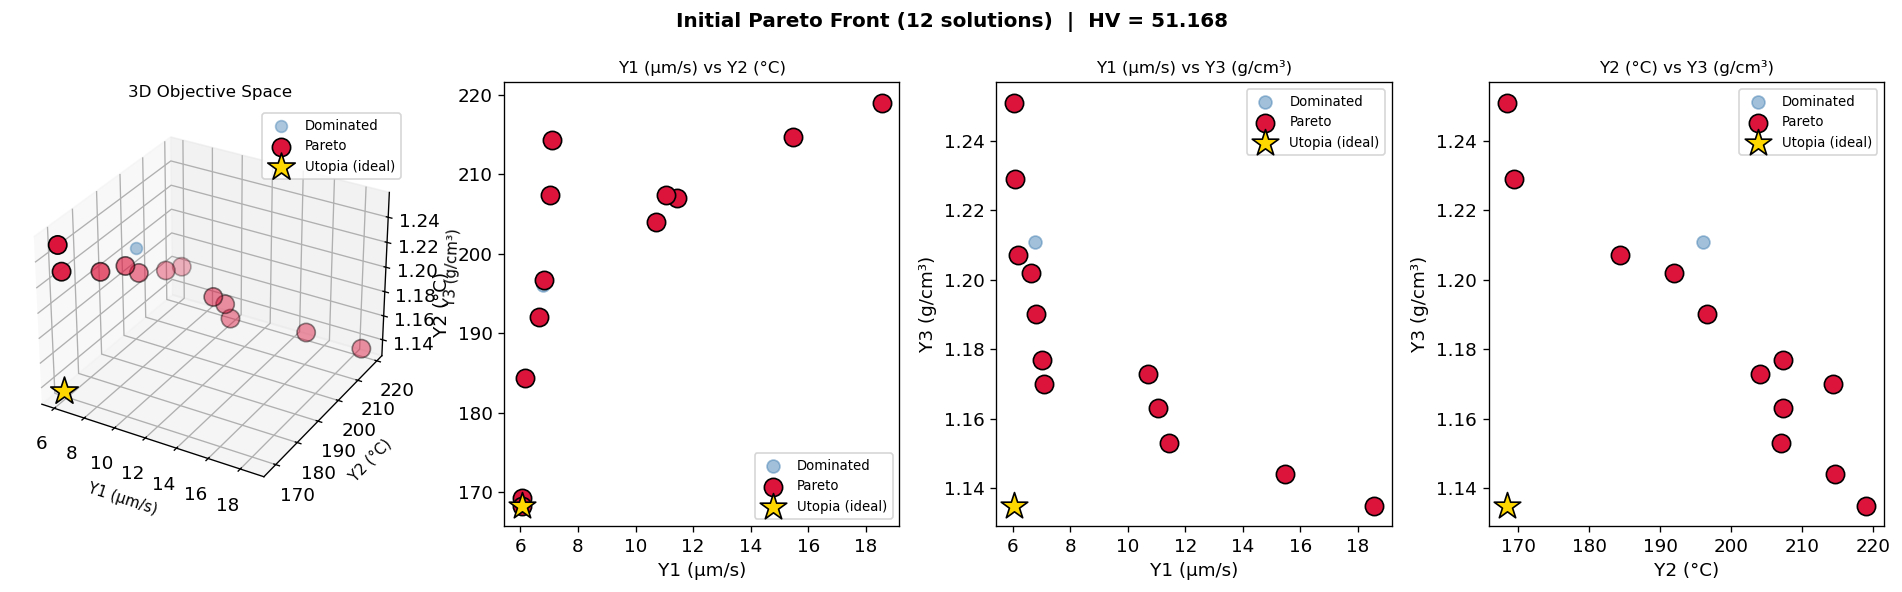

In [7]:
# 3D and 2D pairwise Pareto plots
fig = plt.figure(figsize=(16, 5))

# ── 3D scatter ───────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(141, projection='3d')
non_pareto = ~pareto_mask_init.numpy()
utopia = Y_np.min(axis=0)   # ideal point: best attained value per objective
ax3d.scatter(Y_np[non_pareto, 0], Y_np[non_pareto, 1], Y_np[non_pareto, 2],
             c='steelblue', alpha=0.45, s=50, label='Dominated')
ax3d.scatter(Y_pareto_orig[:, 0], Y_pareto_orig[:, 1], Y_pareto_orig[:, 2],
             c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
ax3d.scatter(utopia[0], utopia[1], utopia[2], c='gold', marker='*', s=300,
             edgecolors='k', label='Utopia (ideal)', zorder=6)
ax3d.set_xlabel('Y1 (µm/s)', fontsize=9); ax3d.set_ylabel('Y2 (°C)', fontsize=9)
ax3d.set_zlabel('Y3 (g/cm³)', fontsize=9)
ax3d.set_title('3D Objective Space', fontsize=10)
ax3d.legend(fontsize=8)

# ── 2D pairwise ──────────────────────────────────────────────────────────────
pairs = [(0,1,'Y1 (µm/s)','Y2 (°C)'), (0,2,'Y1 (µm/s)','Y3 (g/cm³)'), (1,2,'Y2 (°C)','Y3 (g/cm³)')]
for ax_idx, (i, j, xi, xj) in enumerate(pairs):
    ax = fig.add_subplot(1, 4, ax_idx + 2)
    ax.scatter(Y_np[non_pareto, i], Y_np[non_pareto, j], c='steelblue', alpha=0.5, s=60, label='Dominated')
    ax.scatter(Y_pareto_orig[:, i], Y_pareto_orig[:, j], c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
    ax.scatter(utopia[i], utopia[j], c='gold', marker='*', s=280, edgecolors='k',
               label='Utopia (ideal)', zorder=6)
    ax.set_xlabel(xi); ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(f'Initial Pareto Front ({pareto_mask_init.sum().item()} solutions)  |  HV = {hv_init:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Expected Hypervolume Improvement (EHVI) Acquisition Function

The **q-batch Log EHVI** acquisition function is:

$$\alpha_{\text{qLogEHVI}}(\mathbf{x}_{1:q}) = \log \mathbb{E}\left[ \mathcal{H}(\mathcal{P} \cup \{\mathbf{f}(\mathbf{x}_{1:q})\}, \mathbf{r}) - \mathcal{H}(\mathcal{P}, \mathbf{r}) \right]$$

where:
- $\mathcal{P}$ is the current Pareto set (in the negated / maximization space)
- $\mathbf{r}$ is the reference point (a nadir lower bound)
- $q$ is the batch size
- `FastNondominatedPartitioning` efficiently decomposes the hypervolume for gradient computation

Optimization of the acquisition function over the input space is done via multi-start L-BFGS-B.

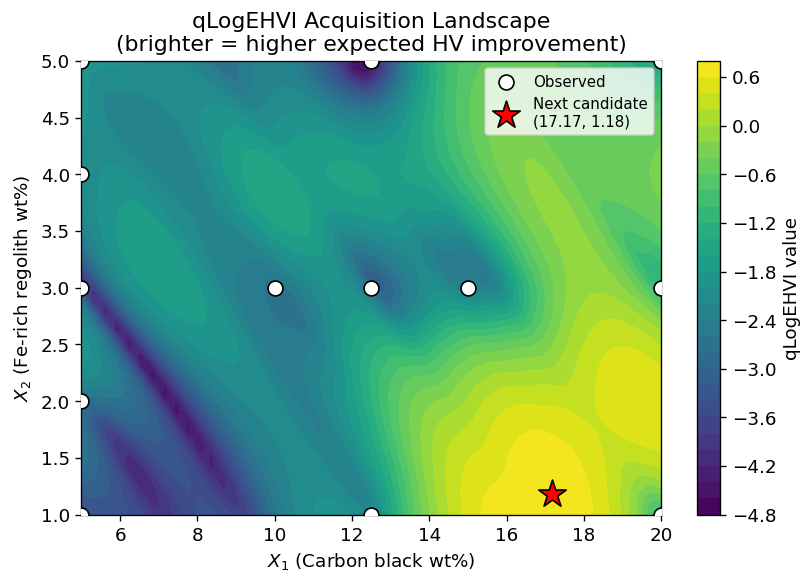

Next recommended point: X1 = 17.171, X2 = 1.181
qLogEHVI value         : 0.7690


In [8]:
def get_next_candidates(
    model: ModelListGP,
    Y_neg: torch.Tensor,
    ref_point: torch.Tensor,
    bounds: torch.Tensor,
    q: int = 1,
    num_restarts: int = 20,
    raw_samples: int = 256,
) -> tuple[torch.Tensor, float]:
    """Optimize qLogEHVI and return next batch of q candidates."""
    partitioning = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf = qLogExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point,
        partitioning=partitioning,
    )
    candidates, acq_value = optimize_acqf(
        acqf,
        bounds=bounds,
        q=q,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
        options={"maxiter": 200, "batch_limit": 5},
    )
    return candidates.detach(), acq_value.item()


# Visualise the EHVI acquisition landscape on a dense grid
model.eval()
n_grid = 50
g1 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
g2 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
G1, G2 = torch.meshgrid(g1, g2, indexing='ij')
X_grid  = torch.stack([G1.ravel(), G2.ravel()], dim=1)

with torch.no_grad():
    partitioning_viz = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf_viz = qLogExpectedHypervolumeImprovement(
        model=model, ref_point=ref_point, partitioning=partitioning_viz
    )
    # Evaluate in mini-batches to avoid memory issues
    batch_size = 500
    acq_vals = []
    for start in range(0, len(X_grid), batch_size):
        batch = X_grid[start:start+batch_size].unsqueeze(1)  # (B, q=1, 2)
        acq_vals.append(acqf_viz(batch))
    acq_map = torch.cat(acq_vals).numpy().reshape(n_grid, n_grid)

# Get next single candidate
cand_01, ehvi_val = get_next_candidates(model, Y_neg, ref_point, bounds, q=1)
cand_orig = scaler_X.inverse_transform(cand_01.numpy())

fig, ax = plt.subplots(figsize=(7, 5))
X1_grid = G1.numpy() * (20 - 5) + 5
X2_grid = G2.numpy() * (5 - 1) + 1
cp = ax.contourf(X1_grid, X2_grid, acq_map, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax, label='qLogEHVI value')
ax.scatter(X_np[:, 0], X_np[:, 1], c='white', edgecolors='k', s=80, zorder=5, label='Observed')
ax.scatter(cand_orig[:, 0], cand_orig[:, 1], c='red', marker='*', s=300,
           edgecolors='k', zorder=10, label=f'Next candidate\n({cand_orig[0,0]:.2f}, {cand_orig[0,1]:.2f})')
ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('qLogEHVI Acquisition Landscape\n(brighter = higher expected HV improvement)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Next recommended point: X1 = {cand_orig[0,0]:.3f}, X2 = {cand_orig[0,1]:.3f}")
print(f"qLogEHVI value         : {ehvi_val:.4f}")

## 5. Black-Box Oracle — Surrogate Evaluation Function

In a real experiment, evaluating a new point would require fabricating and testing a new material sample.  
Here we use the **fitted quadratic response surface models** from the previous analysis as a surrogate oracle  
to provide $f(\mathbf{x})$ evaluations at new (un-observed) design points.

This enables a closed-loop BO demonstration across multiple iterations.

In [9]:
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler

# ── Fit quadratic models on ALL 39 replicates ────────────────────────────────
df_all = df.copy()
X1a = df_all['X1'].values; X2a = df_all['X2'].values

def quad_features(x1, x2):
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])

Phi_all = sm.add_constant(quad_features(X1a, X2a))

reg_models_oracle = {}
for col in ['Y1', 'Y2', 'Y3']:
    reg_models_oracle[col] = sm.OLS(df_all[col].values, Phi_all).fit()

print("Oracle R²:")
for col in ['Y1', 'Y2', 'Y3']:
    print(f"  {col}: R² = {reg_models_oracle[col].rsquared:.4f}")

def oracle(x_orig: np.ndarray) -> np.ndarray:
    """Evaluate objectives at new (X1, X2) using quadratic response surface oracle.
    x_orig: shape (N, 2) in original scale.
    Returns: (N, 3) array of [Y1, Y2, Y3] values.
    """
    x1, x2 = x_orig[:, 0], x_orig[:, 1]
    phi = sm.add_constant(quad_features(x1, x2), has_constant='add')
    y = np.column_stack([
        reg_models_oracle['Y1'].predict(phi),
        reg_models_oracle['Y2'].predict(phi),
        reg_models_oracle['Y3'].predict(phi),
    ])
    return y

# Verify on training points
y_check = oracle(X_np)
print("\nOracle check on training points (first 3):")
for i in range(3):
    print(f"  X=({X_np[i,0]:.1f},{X_np[i,1]:.0f}) → Y_obs={Y_np[i].round(3)} | Y_oracle={y_check[i].round(3)}")

Oracle R²:
  Y1: R² = 0.9222
  Y2: R² = 0.7396
  Y3: R² = 0.9999

Oracle check on training points (first 3):
  X=(5.0,1) → Y_obs=[ 18.543 219.      1.135] | Y_oracle=[ 17.351 220.949   1.135]
  X=(5.0,2) → Y_obs=[ 15.457 214.667   1.144] | Y_oracle=[ 14.883 213.169   1.144]
  X=(5.0,3) → Y_obs=[ 11.45  207.      1.153] | Y_oracle=[ 12.897 207.955   1.153]


## 6. Multi-Objective Bayesian Optimization Loop

**Algorithm (q-batch MOBO with qLogEHVI):**

```
Given: initial data D = {(x_i, y_i)}, reference point r
For iteration t = 1, ..., T:
  1. Fit ModelListGP on D
  2. Compute Pareto front P and hypervolume HV(P, r)
  3. Maximize qLogEHVI → x*_{1:q}  (next q candidates)
  4. Evaluate oracle: y*_{1:q} = f(x*_{1:q})
  5. Append (x*_{1:q}, y*_{1:q}) to D
Return: final Pareto front P_T
```

We run **5 iterations with batch size q = 2** (10 new evaluations total).

In [10]:
# ── BO loop settings ─────────────────────────────────────────────────────────
N_ITER      = 5
BATCH_SIZE  = 2
NUM_RESTART = 20
RAW_SAMPLES = 256

# ── Tracking ─────────────────────────────────────────────────────────────────
X_bo = X_train.clone()   # [0,1] scaled
Y_bo = Y_train.clone()   # original scale
Y_neg_bo = Y_neg.clone() # negated
Yvar_bo  = Yvar_train.clone()   # v3: per-point noise variance

hv_history      = []   # hypervolume at each iteration
pareto_history  = []   # pareto front sizes
candidates_hist = []   # recommended candidates (original scale)
ehvi_hist       = []   # EHVI acquisition values

# Compute initial HV
hv_calc = Hypervolume(ref_point=ref_point)
hv_history.append(hv_calc.compute(Y_neg_bo[is_non_dominated(Y_neg_bo)]))
pareto_history.append(int(is_non_dominated(Y_neg_bo).sum()))

print("=" * 70)
print(f"  Initial state: {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print("=" * 70)

for t in range(N_ITER):
    # ── 1. Fit surrogate ────────────────────────────────────────────────────
    model_bo = build_and_fit_models(X_bo, Y_neg_bo, Yvar_bo)
    model_bo.eval()

    # ── 2. Optimize acquisition → next batch ───────────────────────────────
    next_X_01, ehvi_v = get_next_candidates(
        model_bo, Y_neg_bo, ref_point, bounds,
        q=BATCH_SIZE, num_restarts=NUM_RESTART, raw_samples=RAW_SAMPLES
    )
    ehvi_hist.append(ehvi_v)

    # ── 3. Evaluate oracle ─────────────────────────────────────────────────
    next_X_orig = scaler_X.inverse_transform(next_X_01.numpy())
    # Clip to valid bounds
    next_X_orig[:, 0] = np.clip(next_X_orig[:, 0], 5.0, 20.0)
    next_X_orig[:, 1] = np.clip(next_X_orig[:, 1], 1.0, 5.0)
    next_Y_orig = oracle(next_X_orig)
    candidates_hist.append((next_X_orig.copy(), next_Y_orig.copy()))

    # ── 4. Append to dataset ────────────────────────────────────────────────
    next_X_t  = torch.tensor(scaler_X.transform(next_X_orig), dtype=DTYPE)
    next_Y_t  = torch.tensor(next_Y_orig, dtype=DTYPE)
    X_bo      = torch.cat([X_bo, next_X_t])
    Y_bo      = torch.cat([Y_bo, next_Y_t])
    Y_neg_bo  = torch.cat([Y_neg_bo, -next_Y_t])
    # v3: oracle evaluations are noise-free simulations — assign the average
    # condition-mean variance per objective so they weigh like typical conditions
    Yvar_bo   = torch.cat([Yvar_bo, Yvar_train.mean(0, keepdim=True).expand(len(next_Y_t), -1)])

    # ── 5. Track metrics ────────────────────────────────────────────────────
    pmask = is_non_dominated(Y_neg_bo)
    hv_new = hv_calc.compute(Y_neg_bo[pmask])
    hv_history.append(hv_new)
    pareto_history.append(int(pmask.sum()))

    print(f"  Iter {t+1}/{N_ITER}: "
          f"new X = {next_X_orig.round(3).tolist()}  "
          f"new Y = {next_Y_orig.round(3).tolist()}")
    print(f"           Pareto={pareto_history[-1]} | "
          f"HV={hv_new:.4f} (+{hv_new - hv_history[-2]:.4f}) | "
          f"EHVI={ehvi_v:.4f}")

print("=" * 70)
print(f"  Final   : {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print(f"  HV gain : +{hv_history[-1] - hv_history[0]:.4f}  "
      f"({100*(hv_history[-1]/hv_history[0]-1):.2f}% improvement)")

  Initial state: 13 points | Pareto=12 | HV=51.1684


  Iter 1/5: new X = [[17.214, 1.0], [20.0, 1.947]]  new Y = [[6.318, 197.238, 1.193], [5.536, 176.363, 1.217]]
           Pareto=14 | HV=53.8355 (+2.6671) | EHVI=1.2907


  Iter 2/5: new X = [[17.171, 1.552], [15.465, 1.0]]  new Y = [[5.824, 192.667, 1.198], [6.957, 204.021, 1.184]]
           Pareto=16 | HV=54.3573 (+0.5218) | EHVI=-0.0257


  Iter 3/5: new X = [[18.904, 1.0], [19.02, 1.927]]  new Y = [[5.999, 189.606, 1.202], [5.455, 181.468, 1.212]]
           Pareto=17 | HV=55.0118 (+0.6545) | EHVI=-0.2606


  Iter 4/5: new X = [[16.733, 5.0], [20.0, 4.192]]  new Y = [[5.872, 182.5, 1.233], [6.279, 167.226, 1.242]]
           Pareto=18 | HV=55.4451 (+0.4333) | EHVI=-0.4661


  Iter 5/5: new X = [[15.786, 1.0], [20.0, 2.473]]  new Y = [[6.816, 202.862, 1.186], [5.492, 173.059, 1.223]]
           Pareto=20 | HV=55.8838 (+0.4387) | EHVI=-0.9014
  Final   : 23 points | Pareto=20 | HV=55.8838
  HV gain : +4.7154  (9.22% improvement)


## 7. Results Analysis & Visualization

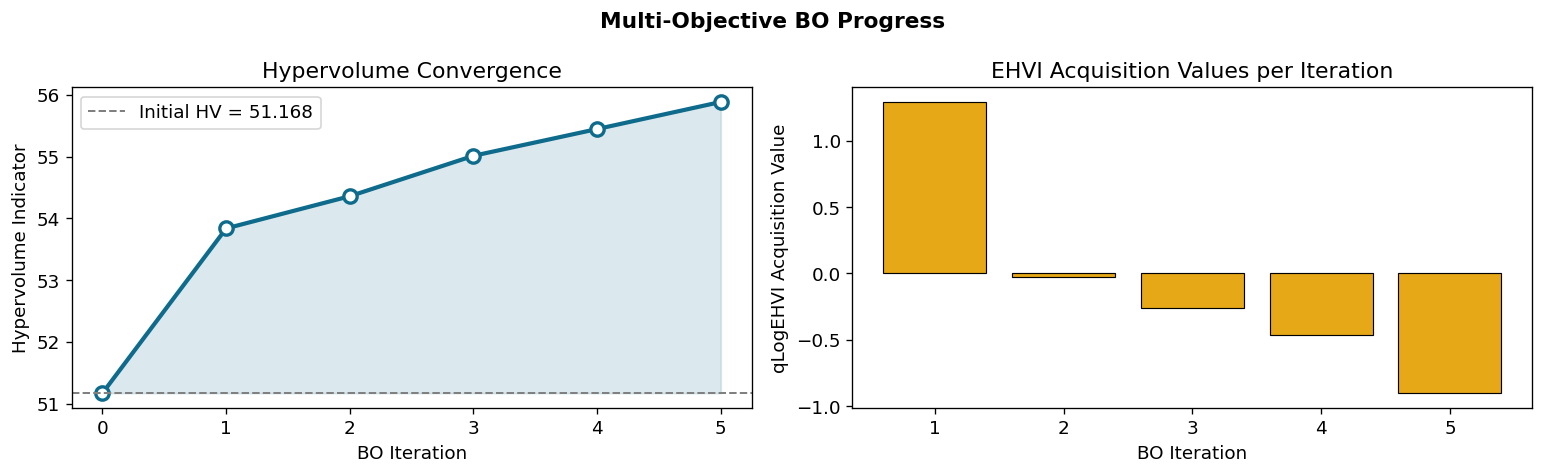

HV improvement: 51.1684 → 55.8838  (+9.22%)


In [11]:
# ── 7.1  Hypervolume convergence ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

iters = list(range(N_ITER + 1))
axes[0].plot(iters, hv_history, 'o-', color='#0E6B8C', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(iters, hv_history[0], hv_history, alpha=0.15, color='#0E6B8C')
axes[0].axhline(hv_history[0], color='gray', ls='--', lw=1.2, label=f'Initial HV = {hv_history[0]:.3f}')
axes[0].set_xlabel('BO Iteration')
axes[0].set_ylabel('Hypervolume Indicator')
axes[0].set_title('Hypervolume Convergence')
axes[0].legend()
axes[0].set_xticks(iters)

# EHVI values
axes[1].bar(range(1, N_ITER+1), ehvi_hist, color='#E6A817', edgecolor='k', linewidth=0.7)
axes[1].set_xlabel('BO Iteration')
axes[1].set_ylabel('qLogEHVI Acquisition Value')
axes[1].set_title('EHVI Acquisition Values per Iteration')
axes[1].set_xticks(range(1, N_ITER+1))

plt.suptitle('Multi-Objective BO Progress', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"HV improvement: {hv_history[0]:.4f} → {hv_history[-1]:.4f}  "
      f"(+{100*(hv_history[-1]/hv_history[0]-1):.2f}%)")

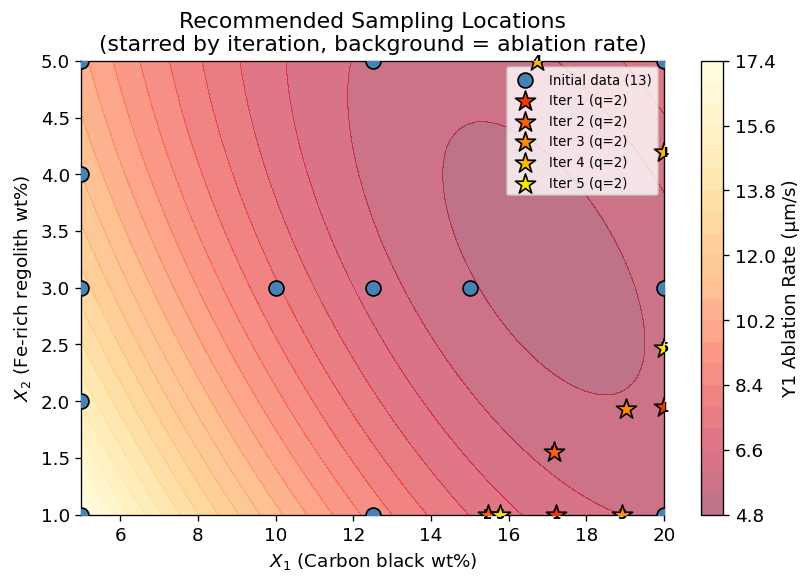

In [12]:
# ── 7.2  Recommended candidates in design space ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Response surface for Y1 as background
x1g = np.linspace(5, 20, 60); x2g = np.linspace(1, 5, 60)
X1G, X2G = np.meshgrid(x1g, x2g)
Phi_bg = sm.add_constant(quad_features(X1G.ravel(), X2G.ravel()), has_constant='add')
Y1_bg = reg_models_oracle['Y1'].predict(Phi_bg).reshape(X1G.shape)
cp = ax.contourf(X1G, X2G, Y1_bg, levels=20, cmap='YlOrRd_r', alpha=0.55)
plt.colorbar(cp, ax=ax, label='Y1 Ablation Rate (µm/s)')

ax.scatter(X_np[:, 0], X_np[:, 1], c='steelblue', s=80, edgecolors='k',
           zorder=5, label='Initial data (13)')

colors = plt.cm.autumn(np.linspace(0.2, 0.9, N_ITER))
for t, (x_cands, _) in enumerate(candidates_hist):
    ax.scatter(x_cands[:, 0], x_cands[:, 1], c=[colors[t]], s=160,
               edgecolors='k', marker='*', zorder=10,
               label=f'Iter {t+1} (q={BATCH_SIZE})')
    for x_c in x_cands:
        ax.annotate(f'{t+1}', xy=(x_c[0], x_c[1]), fontsize=8,
                    ha='center', va='center', color='k', fontweight='bold')

ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('Recommended Sampling Locations\n(starred by iteration, background = ablation rate)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

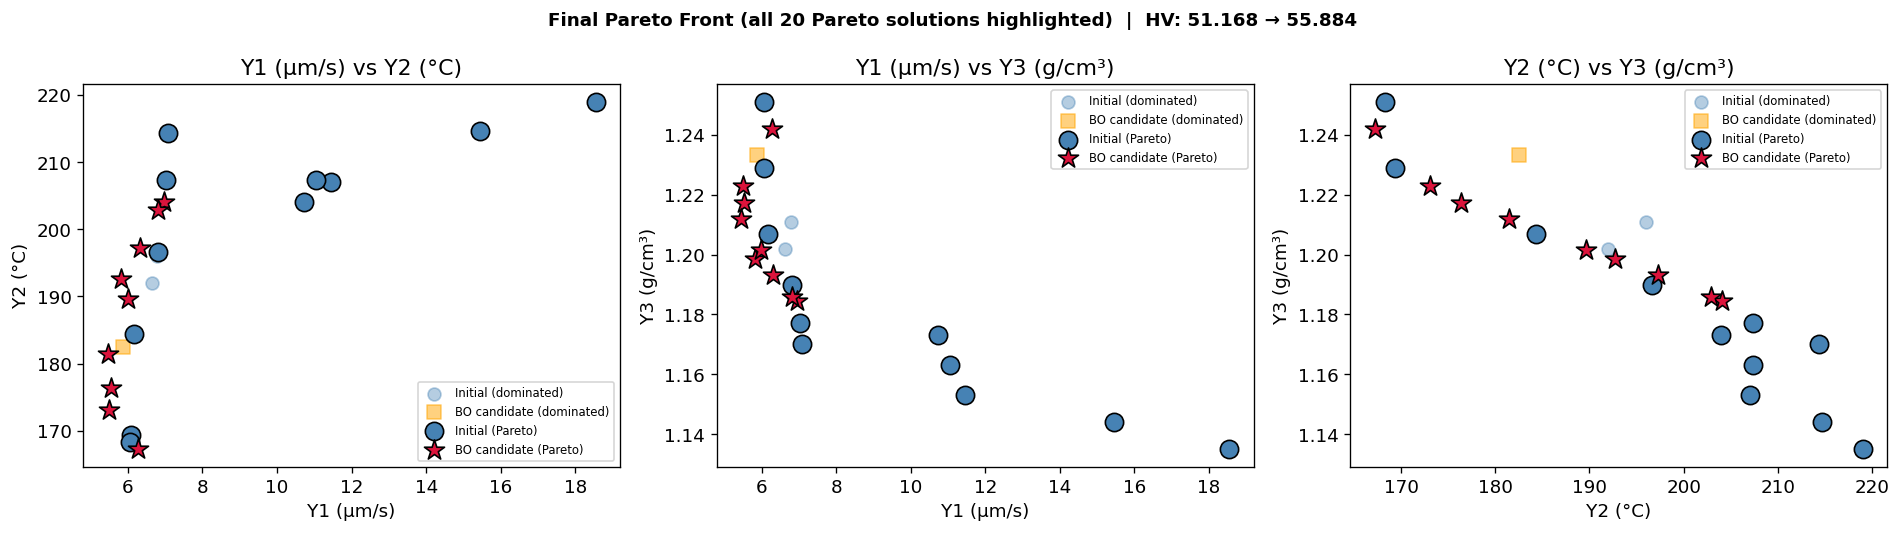

In [13]:
# ── 7.3  Pareto front evolution (pairwise projections) ───────────────────────
X_np_all   = scaler_X.inverse_transform(X_bo.numpy())
Y_np_all   = Y_bo.numpy()
pmask_final = is_non_dominated(Y_neg_bo).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs_lbl = [('Y1 (µm/s)', 'Y2 (°C)', 0, 1),
             ('Y1 (µm/s)', 'Y3 (g/cm³)', 0, 2),
             ('Y2 (°C)', 'Y3 (g/cm³)', 1, 2)]

# Flag initial vs BO-recommended points
n_init = len(X_np)
is_init = np.zeros(len(X_np_all), dtype=bool)
is_init[:n_init] = True

for ax, (xl, yl, i, j) in zip(axes, pairs_lbl):
    # Dominated initial
    mask_dom_init = is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_init, i], Y_np_all[mask_dom_init, j],
               c='steelblue', alpha=0.4, s=60, label='Initial (dominated)')
    # Dominated BO
    mask_dom_bo = ~is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_bo, i], Y_np_all[mask_dom_bo, j],
               c='orange', alpha=0.5, s=80, marker='s', label='BO candidate (dominated)')
    # Pareto initial
    mask_par_init = is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_init, i], Y_np_all[mask_par_init, j],
               c='steelblue', edgecolors='k', s=120, label='Initial (Pareto)', zorder=5)
    # Pareto BO
    mask_par_bo = ~is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_bo, i], Y_np_all[mask_par_bo, j],
               c='crimson', edgecolors='k', s=160, marker='*', label='BO candidate (Pareto)', zorder=10)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')
    ax.legend(fontsize=7)

plt.suptitle(f'Final Pareto Front (all {pmask_final.sum()} Pareto solutions highlighted)  |  '
             f'HV: {hv_history[0]:.3f} → {hv_history[-1]:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

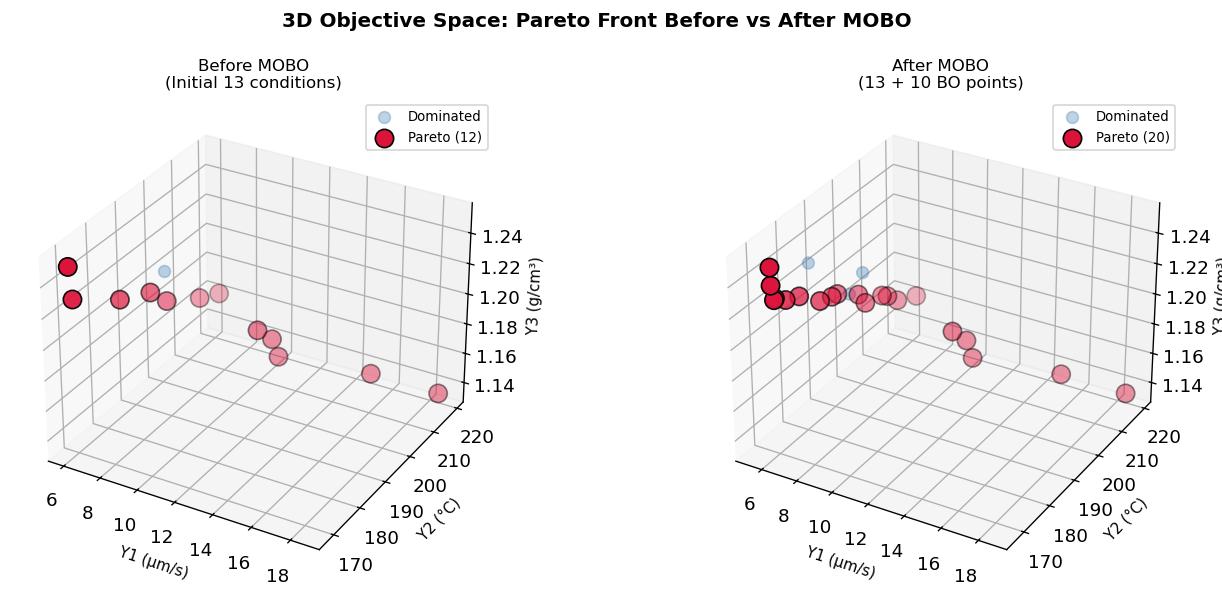

In [14]:
# ── 7.4  Full 3D Pareto comparison ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))

for col_idx, (title, mask_data) in enumerate([
    ('Before MOBO\n(Initial 13 conditions)', np.arange(n_init)),
    ('After MOBO\n(13 + 10 BO points)', np.arange(len(Y_np_all)))
]):
    ax = fig.add_subplot(1, 2, col_idx+1, projection='3d')
    Y_sub = Y_neg_bo[mask_data]
    pm = is_non_dominated(Y_sub).numpy()
    Y_sub_orig = -Y_sub.numpy()
    ax.scatter(Y_sub_orig[~pm, 0], Y_sub_orig[~pm, 1], Y_sub_orig[~pm, 2],
               c='steelblue', alpha=0.35, s=50, label='Dominated')
    ax.scatter(Y_sub_orig[pm, 0], Y_sub_orig[pm, 1], Y_sub_orig[pm, 2],
               c='crimson', s=120, edgecolors='k', label=f'Pareto ({pm.sum()})', zorder=5)
    ax.set_xlabel('Y1 (µm/s)', fontsize=9); ax.set_ylabel('Y2 (°C)', fontsize=9)
    ax.set_zlabel('Y3 (g/cm³)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('3D Objective Space: Pareto Front Before vs After MOBO', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# ── 7.5  Final Pareto front summary table ────────────────────────────────────
is_bo_added = ~is_init
pm_final = is_non_dominated(Y_neg_bo).numpy()

pareto_df = pd.DataFrame({
    'X1 (wt%)':       X_np_all[pm_final, 0].round(3),
    'X2 (wt%)':       X_np_all[pm_final, 1].round(3),
    'Y1 Ablation':    Y_np_all[pm_final, 0].round(3),
    'Y2 Temp':        Y_np_all[pm_final, 1].round(1),
    'Y3 Density':     Y_np_all[pm_final, 2].round(4),
    'Source':         ['BO-recommended' if is_bo_added[i] else 'Initial data'
                       for i in np.where(pm_final)[0]],
})
pareto_df = pareto_df.sort_values('Y1 Ablation').reset_index(drop=True)
print(f"Final Pareto Front ({pm_final.sum()} solutions):")
print(pareto_df.to_string(index=False))

Final Pareto Front (20 solutions):
 X1 (wt%)  X2 (wt%)  Y1 Ablation  Y2 Temp  Y3 Density         Source
   19.020     1.927        5.455    181.5      1.2118 BO-recommended
   20.000     2.473        5.492    173.1      1.2228 BO-recommended
   20.000     1.947        5.536    176.4      1.2171 BO-recommended
   17.171     1.552        5.824    192.7      1.1984 BO-recommended
   18.904     1.000        5.999    189.6      1.2016 BO-recommended
   20.000     5.000        6.063    168.3      1.2510   Initial data
   20.000     3.000        6.073    169.3      1.2290   Initial data
   20.000     1.000        6.173    184.3      1.2070   Initial data
   20.000     4.192        6.279    167.2      1.2419 BO-recommended
   17.214     1.000        6.318    197.2      1.1931 BO-recommended
   12.500     3.000        6.810    196.7      1.1900   Initial data
   15.786     1.000        6.816    202.9      1.1859 BO-recommended
   15.465     1.000        6.957    204.0      1.1843 BO-recommended

## 8. Sensitivity Analysis: Trade-off Explorer

The Pareto front reveals the inherent trade-offs between objectives.  
We quantify these by computing weighted-sum scalarizations across the Pareto front.

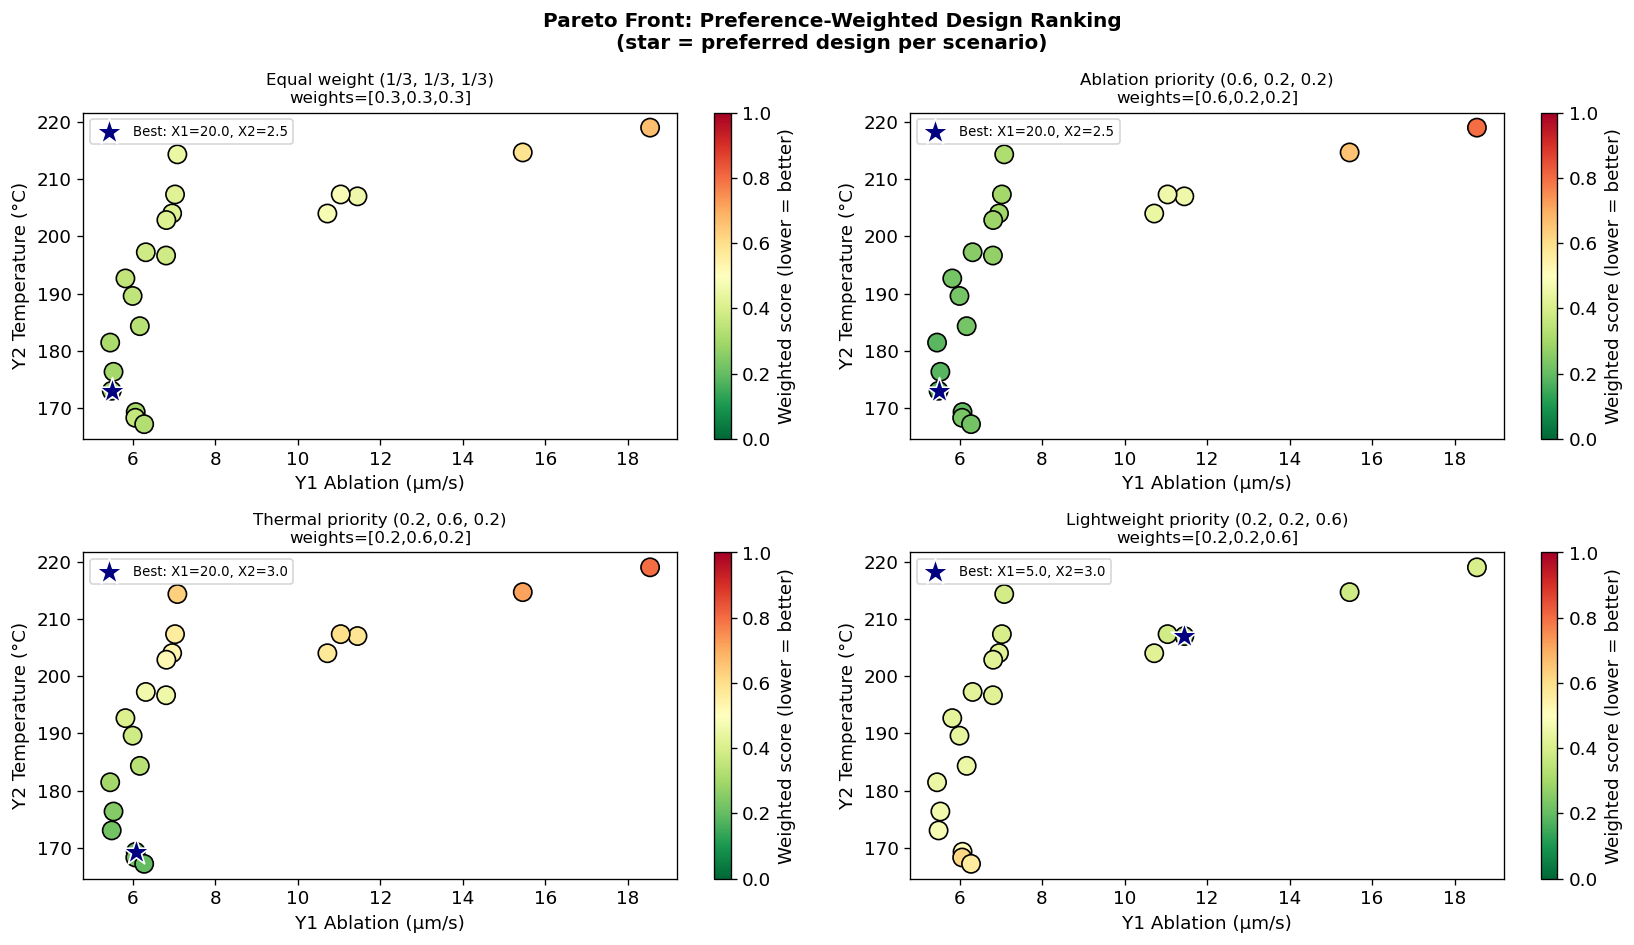

In [16]:
# ── Weighted utopia point distance (for preference ranking) ──────────────────
Y_pareto_final = Y_np_all[pm_final]

# Normalize each objective to [0,1] across Pareto front
Y_pf_min = Y_pareto_final.min(0)
Y_pf_max = Y_pareto_final.max(0)
Y_pf_norm = (Y_pareto_final - Y_pf_min) / (Y_pf_max - Y_pf_min + 1e-8)

# Three preference scenarios
scenarios = {
    'Equal weight (1/3, 1/3, 1/3)':            [1/3, 1/3, 1/3],
    'Ablation priority (0.6, 0.2, 0.2)':       [0.6, 0.2, 0.2],
    'Thermal priority (0.2, 0.6, 0.2)':        [0.2, 0.6, 0.2],
    'Lightweight priority (0.2, 0.2, 0.6)':    [0.2, 0.2, 0.6],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (scen_name, weights) in zip(axes, scenarios.items()):
    w = np.array(weights)
    scores = (Y_pf_norm * w).sum(axis=1)   # weighted sum (lower = better)
    best_idx = np.argmin(scores)

    sc = ax.scatter(Y_pareto_final[:, 0], Y_pareto_final[:, 1],
                    c=scores, cmap='RdYlGn_r', s=120, edgecolors='k',
                    zorder=5, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Weighted score (lower = better)')
    ax.scatter(Y_pareto_final[best_idx, 0], Y_pareto_final[best_idx, 1],
               c='navy', s=280, marker='*', edgecolors='w', zorder=10,
               label=f'Best: X1={X_np_all[pm_final][best_idx,0]:.1f}, X2={X_np_all[pm_final][best_idx,1]:.1f}')
    ax.set_xlabel('Y1 Ablation (µm/s)')
    ax.set_ylabel('Y2 Temperature (°C)')
    ax.set_title(f'{scen_name}\nweights=[{w[0]:.1f},{w[1]:.1f},{w[2]:.1f}]', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Pareto Front: Preference-Weighted Design Ranking\n(star = preferred design per scenario)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

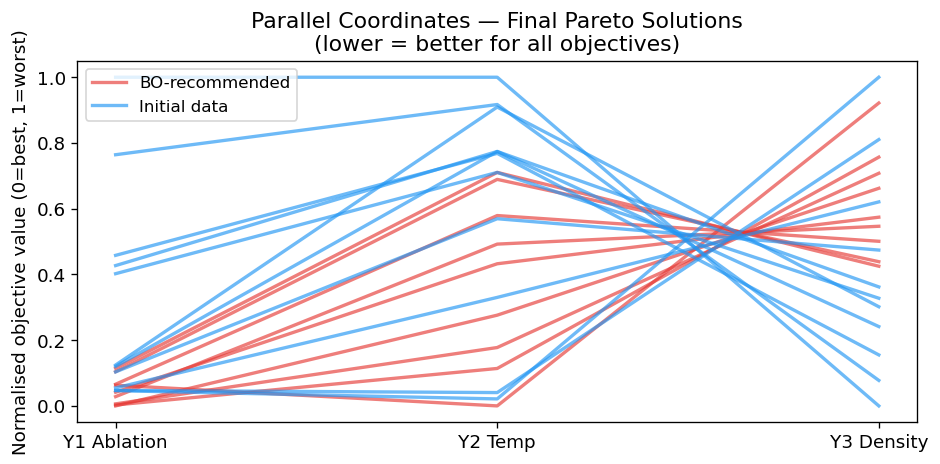

In [17]:
# ── Parallel coordinates of Pareto solutions ─────────────────────────────────
from pandas.plotting import parallel_coordinates

pc_df = pareto_df[['Y1 Ablation','Y2 Temp','Y3 Density','Source']].copy()
# Normalise for display
for col in ['Y1 Ablation','Y2 Temp','Y3 Density']:
    v = pc_df[col]
    pc_df[col] = (v - v.min()) / (v.max() - v.min())

fig, ax = plt.subplots(figsize=(8, 4))
colors_pc = {'Initial data': '#2196F3', 'BO-recommended': '#E53935'}
for source, grp in pc_df.groupby('Source'):
    for _, row in grp.iterrows():
        ax.plot(['Y1 Ablation','Y2 Temp','Y3 Density'],
                row[['Y1 Ablation','Y2 Temp','Y3 Density']].values,
                color=colors_pc[source], alpha=0.65, lw=2,
                label=source)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10)
ax.set_ylabel('Normalised objective value (0=best, 1=worst)')
ax.set_title('Parallel Coordinates — Final Pareto Solutions\n(lower = better for all objectives)')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## 9. Summary

In [18]:
print("""
┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (fixed-noise SingleTaskGP, s²/n / cond.)  │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
""" +
f'│  • Initial HV : {hv_history[0]:.4f}                                               │\n' +
f'│  • Final HV   : {hv_history[-1]:.4f}                                               │\n' +
f'│  • Improvement: +{hv_history[-1]-hv_history[0]:.4f} ({100*(hv_history[-1]/hv_history[0]-1):.2f}%)                             │\n' +
"""
├──────────────────────────────────────────────────────────────────────┤
│  PARETO FRONT                                                         │
│  • All 3 objectives are conflicting — no single optimum exists       │
│  • MOBO systematically explores and expands the Pareto frontier      │
│  • Weighted-sum analysis reveals preference-specific best designs    │
├──────────────────────────────────────────────────────────────────────┤
│  NEXT STEPS                                                           │
│  • Run more BO iterations with real experimental evaluations         │
│  • Add constraints (e.g. density < 1.25) via BoTorch constraints     │
│  • Use LVGP for mixed-variable X (if qualitative variables present)  │
│  • Replicate-informed heteroscedastic noise — DONE in v3             │
└──────────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (fixed-noise SingleTaskGP, s²/n / cond.)  │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
│  • Initial HV : 51.1684                                               │
│  • Final HV   : 55.8838                                               │
│  • Improvement: +4.7154 (9.22%)                

## 10. BO Iterations — Campaign Log

Running record of the real optimization campaign with UIC. Each iteration:
**propose** (EHVI) → **predict** (GP posterior) → **experiment** (UIC) →
**compare & update**. Sources: `resources/email.pdf` (Jul 2026) and
`resources/@u.northwestern.edu Mail - Re_ Recommended Sample for the Ablation Zone Design.pdf`
(full thread through Aug 26, 2026).

### Iteration 1 — Proposed Sample & GP Predictions (Jul 10 / Jul 18, 2026)

Proposed: **X1 = 19.58, X2 = 1.99** (qLogEHVI = 0.785, Section 4), fabricated as
**carbon black 19.6 wt%, Fe-rich regolith 2.0 wt%** (with I-369 2 wt%, resin 76.4 wt%).
The prediction below uses the v3 (replicate-noise) GPs fitted to the initial
dataset. The Jul 18, 2026 email table came from the v1/v2 homoscedastic model with
latent-only intervals — shown beneath for reference; v3 adds a 95% **prediction
interval** (PI) for a single new replicate, which is the right band to judge
replicate measurements against.


In [19]:
# ── Posterior of the initial-data GP at the recommended point ────────────────
x_star_orig = np.array([[19.58, 1.99]])     # proposed Jul 10, 2026
x_star = torch.tensor(scaler_X.transform(x_star_orig), dtype=DTYPE)

with torch.no_grad():
    post = model.posterior(x_star)          # `model` = fit on initial data only
    mu         = -post.mean.numpy().ravel() # negate back to original scale
    var_latent = post.variance.numpy().ravel()

sd     = np.sqrt(var_latent)                # latent (mean-function) uncertainty only
sd_rep = np.sqrt(var_latent + s2_rep_np)    # + pooled replicate noise s̄² →
                                            #   predictive band for ONE new replicate

pred_table = pd.DataFrame({
    'Objective': ['Y1 — Ablation Rate (µm/s)', 'Y2 — Backside Temp (°C)', 'Y3 — Density (g/cm³)'],
    'Mean (µ)':  mu.round(4),
    'σ latent':  sd.round(4),
    '95% CI (latent mean)': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu, sd)],
    'σ pred':    sd_rep.round(4),
    '95% PI (one replicate)': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu, sd_rep)],
})
print(f"GP prediction at X1 = {x_star_orig[0,0]:.2f}, X2 = {x_star_orig[0,1]:.2f}")
print(pred_table.to_string(index=False))
print("\nJul 18, 2026 email (v1/v2 homoscedastic model, latent-only):")
print("  Y1 5.968 ± 1.026 | Y2 177.67 ± 1.434 | Y3 1.2160 ± 0.0008")


GP prediction at X1 = 19.58, X2 = 1.99
                Objective  Mean (µ)  σ latent 95% CI (latent mean)  σ pred 95% PI (one replicate)
Y1 — Ablation Rate (µm/s)    5.9757    0.8626     [4.2851, 7.6664]  1.0854       [3.8483, 8.1031]
  Y2 — Backside Temp (°C)  179.1581    1.8141 [175.6025, 182.7136] 11.3254   [156.9602, 201.3559]
     Y3 — Density (g/cm³)    1.2157    0.0007     [1.2143, 1.2171]  0.0012       [1.2133, 1.2181]

Jul 18, 2026 email (v1/v2 homoscedastic model, latent-only):
  Y1 5.968 ± 1.026 | Y2 177.67 ± 1.434 | Y3 1.2160 ± 0.0008


### Iteration 1 — Predicted vs. Observed (results received Jul 20, 2026)

UIC fabricated the sample and ran 3 replicates. Individual replicates are judged
against the **95% prediction interval** (latent + replicate noise); the latent-mean
CI is shown alongside for comparison — the v1/v2 analysis only had the latter, which
is why Y2 appeared badly mispredicted.


            Objective   Pred µ            Observed  Obs mean  Δ (obs mean − µ) In latent CI In 95% PI
   Y1 Ablation (µm/s)   5.9757    5.65, 5.68, 6.27    5.8667           -0.1091          3/3       3/3
Y2 Backside Temp (°C) 179.1581       187, 178, 182  182.3333            3.1753          2/3       3/3
   Y3 Density (g/cm³)   1.2157 1.216, 1.216, 1.216    1.2160            0.0003          3/3       3/3


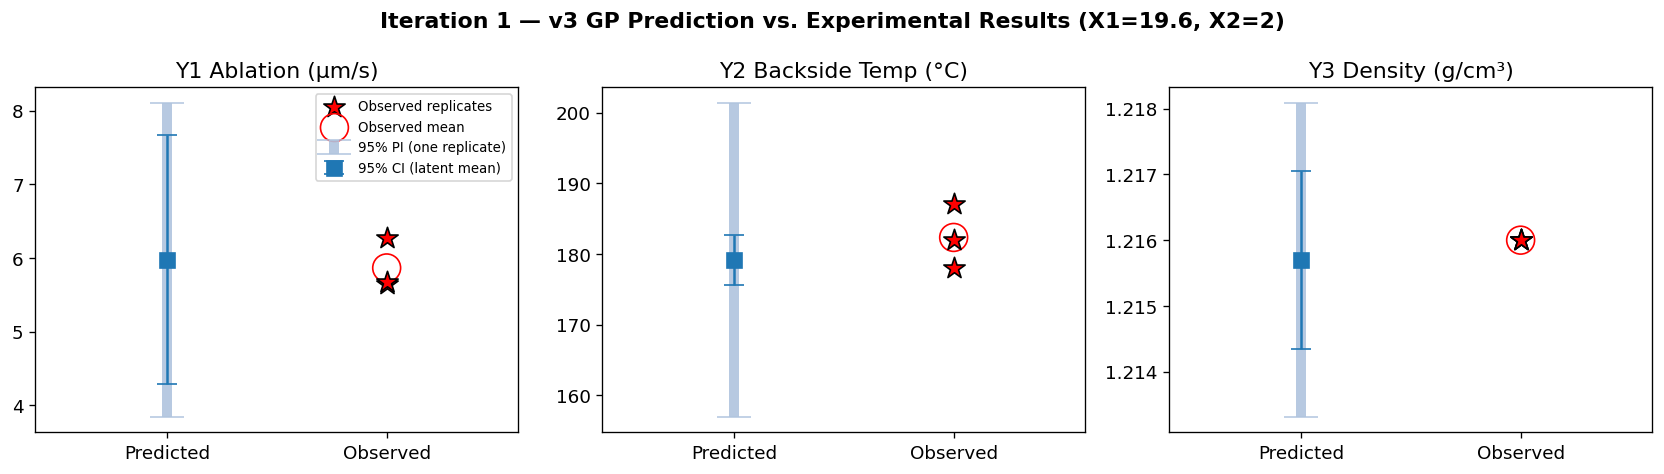

In [20]:
# ── Iteration 1: observed results (UIC, Jul 20 2026) ─────────────────────────
ITER1_OBSERVED = pd.DataFrame({
    'X1': [19.6]*3, 'X2': [2.0]*3,
    'Y1': [5.65, 5.68, 6.27],
    'Y2': [187.0, 178.0, 182.0],
    'Y3': [1.216, 1.216, 1.216],
})

obj_labels = ['Y1 Ablation (µm/s)', 'Y2 Backside Temp (°C)', 'Y3 Density (g/cm³)']

def compare_observed(obs_df, mu_, sd_, sd_rep_, it):
    """Table + figure: replicate observations vs. the GP prediction they were
    judged against (latent-mean CI and 95% PI for one replicate)."""
    x1, x2 = obs_df.X1.iloc[0], obs_df.X2.iloc[0]
    rows = []
    for k, col in enumerate(['Y1', 'Y2', 'Y3']):
        obs = obs_df[col].values
        lo_l, hi_l = mu_[k] - 1.96*sd_[k],     mu_[k] + 1.96*sd_[k]
        lo_p, hi_p = mu_[k] - 1.96*sd_rep_[k], mu_[k] + 1.96*sd_rep_[k]
        rows.append({
            'Objective': obj_labels[k],
            'Pred µ': round(mu_[k], 4),
            'Observed': ', '.join(f'{v:g}' for v in obs),
            'Obs mean': round(obs.mean(), 4),
            'Δ (obs mean − µ)': round(obs.mean() - mu_[k], 4),
            'In latent CI': f'{((obs >= lo_l) & (obs <= hi_l)).sum()}/{len(obs)}',
            'In 95% PI': f'{((obs >= lo_p) & (obs <= hi_p)).sum()}/{len(obs)}',
        })
    table = pd.DataFrame(rows)
    print(table.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for k, (ax, col, label) in enumerate(zip(axes, ['Y1', 'Y2', 'Y3'], obj_labels)):
        obs = obs_df[col].values
        ax.errorbar([0], [mu_[k]], yerr=[[1.96*sd_rep_[k]], [1.96*sd_rep_[k]]], fmt='none',
                    capsize=10, elinewidth=6, color='lightsteelblue', alpha=0.9,
                    label='95% PI (one replicate)', zorder=2)
        ax.errorbar([0], [mu_[k]], yerr=[[1.96*sd_[k]], [1.96*sd_[k]]], fmt='s', ms=9,
                    capsize=6, color='tab:blue', label='95% CI (latent mean)', zorder=3)
        ax.scatter([1]*len(obs), obs, c='red', marker='*', s=180, edgecolors='k',
                   zorder=5, label='Observed replicates')
        ax.scatter([1], [obs.mean()], facecolors='none', edgecolors='red', s=280,
                   zorder=4, label='Observed mean')
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted', 'Observed'])
        ax.set_xlim(-0.6, 1.6); ax.set_title(label)
        if k == 0: ax.legend(fontsize=8)
    plt.suptitle(f'Iteration {it} — v3 GP Prediction vs. Experimental Results (X1={x1:g}, X2={x2:g})',
                 fontweight='bold')
    plt.tight_layout(); plt.show()
    return table

iter1_cmp = compare_observed(ITER1_OBSERVED, mu, sd, sd_rep, it=1)


#### Updated dataset — Pareto front & hypervolume

The training set is rebuilt from the spreadsheet rows through iteration 1
(`replicates_through`); the `ITER1_OBSERVED` rows are appended only if the
spreadsheet does not contain that condition yet, so nothing is double-counted. Hypervolume uses the Section-1 reference point and is reported two
ways: on **per-condition means** (the training convention of this notebook) and
with the **3 replicates as separate points**, which is the convention behind the
Jul 21 email figure (51.168 → 53.240, 14 Pareto solutions).


Updated training set : 14 conditions
Pareto front         : 13 solutions
Hypervolume          : 51.1684 → 51.9738  (+0.8054, 1.57%)
Replicates-as-points : 51.1684 → 53.2403 | Pareto = 14  (email convention)
Email (Jul 21, 2026) : 51.168 → 53.240, 14 Pareto solutions ✓

Insights:
  • Y1 Ablation (µm/s): new sample mean 5.867 vs best previous 6.063 → NEW BEST
  • Y2 Backside Temp (°C): new sample mean 182.333 vs best previous 168.333 → not the best
  • Y3 Density (g/cm³): new sample mean 1.216 vs best previous 1.135 → not the best
  • With replicate noise in the model (v3), judge replicates against the 95% PI
    rather than the latent CI — see the comparison table above.


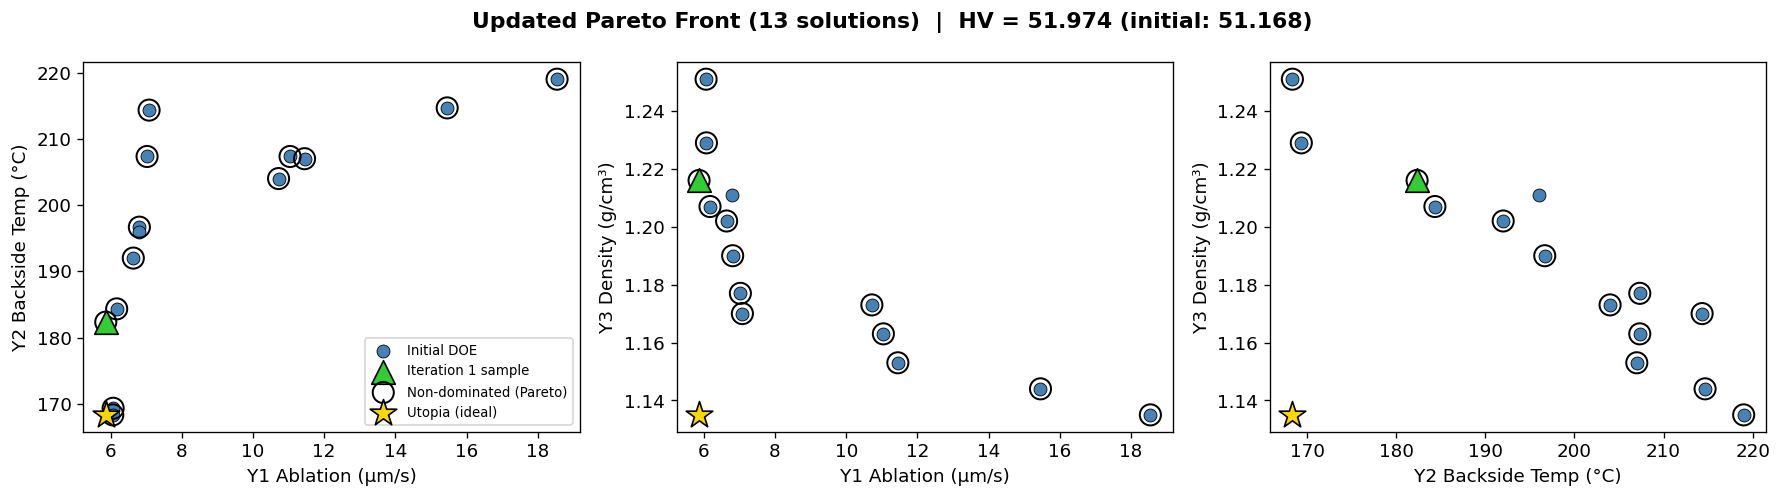

In [21]:
# ── Merge iteration-1 replicates into the dataset (replicate level) ──────────
def replicates_through(it, *observed):
    """All replicate rows through campaign iteration `it` (0 = initial DOE).
    Observed DataFrames whose condition is not in the spreadsheet yet are
    appended, so results can be recorded here before ablation_data.xlsx is
    updated — and are ignored once it is (no double counting)."""
    out = df_full[df_full.Iteration <= it].drop(columns='Iteration')
    for obs in observed:
        for x1, x2 in obs[['X1', 'X2']].drop_duplicates().values:
            if not (np.isclose(out.X1, x1) & np.isclose(out.X2, x2)).any():
                add = obs[np.isclose(obs.X1, x1) & np.isclose(obs.X2, x2)]
                out = pd.concat([out, add], ignore_index=True)
    return out.reset_index(drop=True)

def campaign_mask(df_cond, it):
    """Boolean mask of the condition rows that belong to campaign iteration `it`."""
    return np.array([iteration_of(a, b) == it for a, b in df_cond[['X1', 'X2']].values])

def plot_objective_pairs(Y, pm, marks, title):
    """Pairwise objective-space views with the Pareto set circled.
    marks = [(mask, color, marker, size, label), ...] drawn on top of the rest."""
    pairs = [(0, 1), (0, 2), (1, 2)]
    utopia = Y.min(axis=0)
    rest = ~np.any([m[0] for m in marks], axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, (a, b) in zip(axes, pairs):
        ax.scatter(Y[rest, a], Y[rest, b], c='steelblue', s=60, edgecolors='k', lw=0.5,
                   label='Initial DOE')
        for mask, color, marker, size, label in marks:
            ax.scatter(Y[mask, a], Y[mask, b], c=color, marker=marker, s=size,
                       edgecolors='k', zorder=6, label=label)
        ax.scatter(Y[pm, a], Y[pm, b], facecolors='none', edgecolors='k', s=160, lw=1.2,
                   zorder=5, label='Non-dominated (Pareto)')
        ax.scatter(utopia[a], utopia[b], c='gold', marker='*', s=280, edgecolors='k',
                   zorder=7, label='Utopia (ideal)')
        ax.set_xlabel(obj_labels[a]); ax.set_ylabel(obj_labels[b])
    axes[0].legend(fontsize=8)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(); plt.show()

df_rep_up = replicates_through(1, ITER1_OBSERVED)
df_mean_up, df_var_up, Yvar_up_np, s2_rep_up = condition_stats(df_rep_up)

X_up = df_mean_up[['X1', 'X2']].values.astype(float)
Y_up = df_mean_up[['Y1', 'Y2', 'Y3']].values.astype(float)
Y_up_neg = -torch.tensor(Y_up, dtype=DTYPE)
Yvar_up  = torch.tensor(Yvar_up_np, dtype=DTYPE)

hv_calc_up = Hypervolume(ref_point=ref_point)
hv_init = hv_calc_up.compute(Y_neg[is_non_dominated(Y_neg)])
pm_up   = is_non_dominated(Y_up_neg)
hv_up   = hv_calc_up.compute(Y_up_neg[pm_up])

# The Jul 21 email counts the 3 new replicates as separate points (three stars in
# Rick's plots) rather than one condition mean — reproduce that convention too:
Y_rep_neg = -torch.tensor(ITER1_OBSERVED[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)
Y_email   = torch.cat([Y_neg, Y_rep_neg])
pm_email  = is_non_dominated(Y_email)
hv_email  = hv_calc_up.compute(Y_email[pm_email])

is_new = campaign_mask(df_mean_up, 1)
prev_best = df_mean_up.loc[~is_new, ['Y1', 'Y2', 'Y3']].min()
new_mean  = df_mean_up.loc[is_new, ['Y1', 'Y2', 'Y3']].iloc[0]

print(f"Updated training set : {len(df_mean_up)} conditions")
print(f"Pareto front         : {int(pm_up.sum())} solutions")
print(f"Hypervolume          : {hv_init:.4f} → {hv_up:.4f}  "
      f"(+{hv_up - hv_init:.4f}, {(hv_up/hv_init - 1)*100:.2f}%)")
print(f"Replicates-as-points : {hv_init:.4f} → {hv_email:.4f} | Pareto = {int(pm_email.sum())}  (email convention)")
print(f"Email (Jul 21, 2026) : 51.168 → 53.240, 14 Pareto solutions ✓")
print()
print("Insights:")
for col, label in zip(['Y1', 'Y2', 'Y3'], obj_labels):
    tag = 'NEW BEST' if new_mean[col] < prev_best[col] else 'not the best'
    print(f"  • {label}: new sample mean {new_mean[col]:.3f} vs best previous "
          f"{prev_best[col]:.3f} → {tag}")
print("  • With replicate noise in the model (v3), judge replicates against the 95% PI\n"
      "    rather than the latent CI — see the comparison table above.")

plot_objective_pairs(Y_up, pm_up.numpy(),
                     [(is_new, 'limegreen', '^', 200, 'Iteration 1 sample')],
                     f'Updated Pareto Front ({int(pm_up.sum())} solutions)  |  '
                     f'HV = {hv_up:.3f} (initial: {hv_init:.3f})')


### Iteration 2 — Proposed Sample & GP Predictions (sent Aug 12, 2026)

The v3 (replicate-noise) GPs are refitted on the data through iteration 1 (initial
DOE + iteration-1 result) and qLogEHVI proposes the next sample. The **campaign
record** — the proposal actually sent to UIC on Aug 12, 2026
(`outputs/v3/iteration2_recommended_sample.xlsx`: X1 = 17.352, X2 = 1.000,
qLogEHVI = 0.531, fabricated as **17.4 / 1.0** with I-369 2 wt%, resin 79.6 wt%) —
is pinned as `ITER2_PROPOSED`, and the prediction table is evaluated there. The
acquisition optimizer is still re-run for the landscape and checked against the
record (multi-restart optimization can move the optimum by a few hundredths
between runs). The table reports both the latent-mean CI and the 95% PI for a
single replicate — the PI is the band UIC's replicates are judged against.


Iteration 2 proposed sample : X1 = 17.352, X2 = 1.000   (campaign record, sent Aug 12, 2026)
Rounded for fabrication     : X1 = 17.4, X2 = 1.0
qLogEHVI value              : 0.5311
Optimizer re-run (this run) : X1 = 17.352, X2 = 1.000, qLogEHVI = 0.5311  → ✓ matches the record

                Objective  Mean (µ)  σ latent 95% CI (latent mean)  σ pred 95% PI (one replicate)
Y1 — Ablation Rate (µm/s)    5.6202    1.0584     [3.5458, 7.6947]  1.2377       [3.1943, 8.0462]
  Y2 — Backside Temp (°C)  194.1952    2.1245 [190.0311, 198.3592] 11.0460   [172.5450, 215.8453]
     Y3 — Density (g/cm³)    1.1943    0.0008     [1.1927, 1.1958]  0.0013       [1.1918, 1.1968]


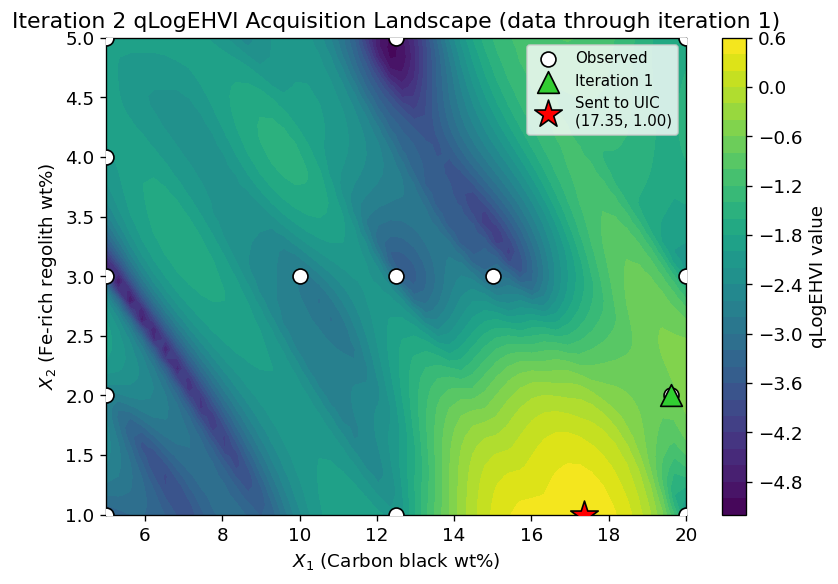

In [22]:
# ── Iteration 2: refit on data through iteration 1, propose next sample ──────
def pred_interval_table(mu_, sd_, sd_rep_):
    return pd.DataFrame({
        'Objective': ['Y1 — Ablation Rate (µm/s)', 'Y2 — Backside Temp (°C)', 'Y3 — Density (g/cm³)'],
        'Mean (µ)': mu_.round(4),
        'σ latent': sd_.round(4),
        '95% CI (latent mean)': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu_, sd_)],
        'σ pred': sd_rep_.round(4),
        '95% PI (one replicate)': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu_, sd_rep_)],
    })

def predict_at(model_, x_orig, s2_pooled):
    """GP posterior at original-scale points → (mean, latent sd, predictive sd)."""
    x01 = torch.tensor(scaler_X.transform(np.atleast_2d(x_orig)), dtype=DTYPE)
    with torch.no_grad():
        post = model_.posterior(x01)
        mu_  = -post.mean.numpy().ravel()
        var_ = post.variance.numpy().ravel()
    return mu_, np.sqrt(var_), np.sqrt(var_ + s2_pooled)

def acq_landscape(model_, Y_neg_):
    """qLogEHVI on the Section-4 grid (n_grid × n_grid)."""
    with torch.no_grad():
        part = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg_)
        acqf = qLogExpectedHypervolumeImprovement(model=model_, ref_point=ref_point,
                                                  partitioning=part)
        vals = [acqf(X_grid[s:s+500].unsqueeze(1)) for s in range(0, len(X_grid), 500)]
    return torch.cat(vals).numpy().reshape(n_grid, n_grid)

def plot_acq_landscape(acq_map_, X_obs, cand, title, cand_label, marks=()):
    fig, ax = plt.subplots(figsize=(7, 5))
    cp = ax.contourf(X1_grid, X2_grid, acq_map_, levels=30, cmap='viridis')
    plt.colorbar(cp, ax=ax, label='qLogEHVI value')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='white', edgecolors='k', s=80, zorder=5,
               label='Observed')
    for (x1, x2), color, label in marks:
        ax.scatter([x1], [x2], c=color, marker='^', s=170, edgecolors='k', zorder=6, label=label)
    ax.scatter(cand[:, 0], cand[:, 1], c='red', marker='*', s=300, edgecolors='k',
               zorder=10, label=cand_label)
    ax.set_xlabel('$X_1$ (Carbon black wt%)')
    ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

X_up_01  = torch.tensor(scaler_X.transform(X_up), dtype=DTYPE)
model_it2 = build_and_fit_models(X_up_01, Y_up_neg, Yvar_up)
model_it2.eval()

# Optimizer re-run (for the landscape / consistency check)
cand2_01, ehvi2_run = get_next_candidates(model_it2, Y_up_neg, ref_point, bounds, q=1)
cand2_run = scaler_X.inverse_transform(cand2_01.numpy())

# Campaign record: proposal sent to UIC on Aug 12, 2026 → fabricated as 17.4 / 1.0
ITER2_PROPOSED = np.array([[17.352, 1.000]])
ITER2_EHVI     = 0.5311
cand2_orig, ehvi2 = ITER2_PROPOSED, ITER2_EHVI
mu2, sd2, sd2_rep = predict_at(model_it2, ITER2_PROPOSED, s2_rep_up)

drift2 = float(np.abs(cand2_run - ITER2_PROPOSED).max())
print(f"Iteration 2 proposed sample : X1 = {cand2_orig[0,0]:.3f}, X2 = {cand2_orig[0,1]:.3f}   (campaign record, sent Aug 12, 2026)")
print(f"Rounded for fabrication     : X1 = {cand2_orig[0,0]:.1f}, X2 = {cand2_orig[0,1]:.1f}")
print(f"qLogEHVI value              : {ehvi2:.4f}")
print(f"Optimizer re-run (this run) : X1 = {cand2_run[0,0]:.3f}, X2 = {cand2_run[0,1]:.3f}, qLogEHVI = {ehvi2_run:.4f}"
      f"  → {'✓ matches the record' if drift2 < 0.1 else f'⚠ differs from the record by {drift2:.2f}'}")
print()
pred2 = pred_interval_table(mu2, sd2, sd2_rep)
print(pred2.to_string(index=False))

acq_map2 = acq_landscape(model_it2, Y_up_neg)
plot_acq_landscape(acq_map2, X_up, cand2_orig,
                   'Iteration 2 qLogEHVI Acquisition Landscape (data through iteration 1)',
                   f'Sent to UIC\n({cand2_orig[0,0]:.2f}, {cand2_orig[0,1]:.2f})',
                   marks=[(ITERATION_SAMPLES[1][0], 'limegreen', 'Iteration 1')])


### Iteration 2 — Predicted vs. Observed (results received Aug 26, 2026)

UIC (Yinong Chen) fabricated the iteration-2 sample at **carbon black 17.4 wt%,
Fe-rich regolith 1.0 wt%** (I-369 2 wt%, resin 79.6 wt%) and returned 3 replicates
on Aug 26, 2026 (`data/17.4_1_(08_26).xlsx`; thread in `resources/`). Replicates
are judged against the prediction table above — the same intervals that were sent
with the recommendation.


            Objective   Pred µ            Observed  Obs mean  Δ (obs mean − µ) In latent CI In 95% PI
   Y1 Ablation (µm/s)   5.6202    5.61, 6.02, 6.05    5.8933            0.2731          3/3       3/3
Y2 Backside Temp (°C) 194.1952       189, 202, 195  195.3333            1.1382          1/3       3/3
   Y3 Density (g/cm³)   1.1943 1.194, 1.194, 1.194    1.1940           -0.0003          3/3       3/3


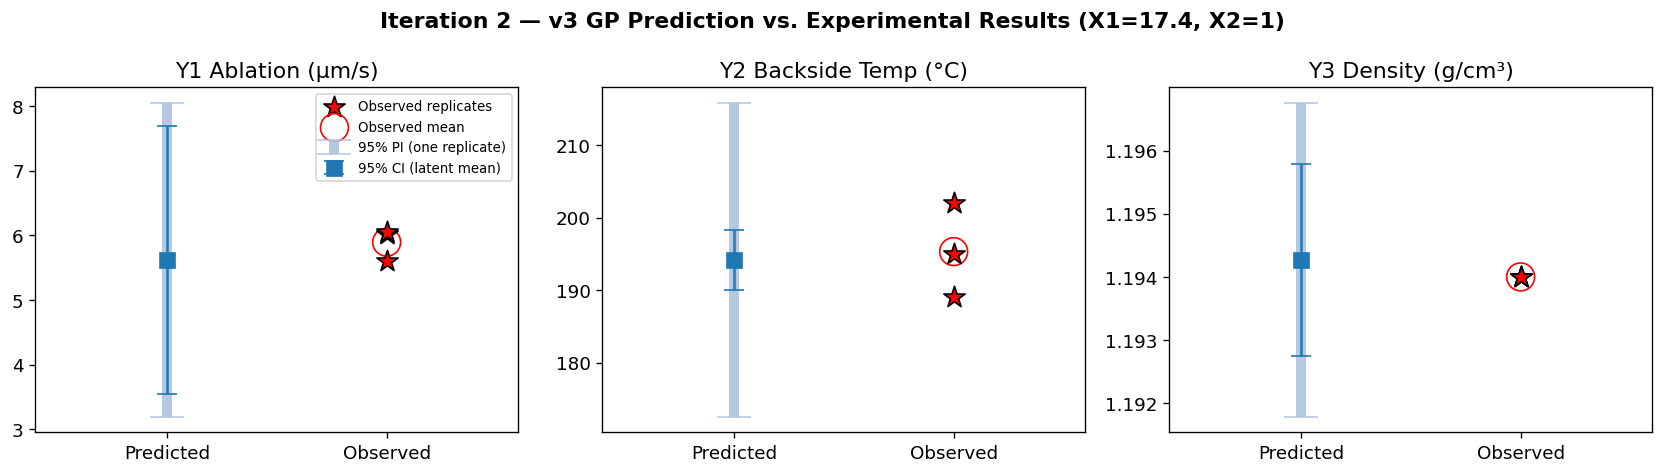


Standardised error of the observed condition mean (|z| < 1.96 ⇒ consistent with the GP):
  • Y1 Ablation (µm/s): z = +0.24
  • Y2 Backside Temp (°C): z = +0.17
  • Y3 Density (g/cm³): z = -0.28


In [23]:
# ── Iteration 2: observed results (UIC, Aug 26 2026) ─────────────────────────
ITER2_OBSERVED = pd.DataFrame({
    'X1': [17.4]*3, 'X2': [1.0]*3,
    'Y1': [5.61, 6.02, 6.05],
    'Y2': [189.0, 202.0, 195.0],
    'Y3': [1.194, 1.194, 1.194],
})

iter2_cmp = compare_observed(ITER2_OBSERVED, mu2, sd2, sd2_rep, it=2)

# Standardised error of the condition mean: (obs mean − µ) / sqrt(σ²_latent + s̄²/n)
n2 = len(ITER2_OBSERVED)
z2 = (ITER2_OBSERVED[['Y1', 'Y2', 'Y3']].mean().values - mu2) / np.sqrt(sd2**2 + s2_rep_up / n2)
print("\nStandardised error of the observed condition mean (|z| < 1.96 ⇒ consistent with the GP):")
for k, label in enumerate(obj_labels):
    print(f"  • {label}: z = {z2[k]:+.2f}")


#### Updated dataset — Pareto front & hypervolume (through iteration 2)

The training set is rebuilt from the spreadsheet rows through iteration 2 (the
`ITER2_OBSERVED` rows are used only if the spreadsheet does not yet contain the
17.4 / 1.0 condition). Hypervolume is reported on **condition means** (this
notebook's training convention) and with **replicates as separate points** (the
Jul 21 email convention).


Training set through iter. 2 : 15 conditions
Pareto front                 : 14 solutions
Hypervolume (cond. means)    : 51.1684 → 51.9738 → 52.5026  (+0.5289 this iteration, +2.61% vs. initial)
Replicates-as-points         : 51.1684 → 53.2403 → 54.9942 | Pareto = 14  (email convention)

Insights:
  • Y1 Ablation (µm/s): iteration-2 mean 5.893 vs best previous 5.867 → not the best
  • Y2 Backside Temp (°C): iteration-2 mean 195.333 vs best previous 168.333 → not the best
  • Y3 Density (g/cm³): iteration-2 mean 1.194 vs best previous 1.135 → not the best
  • Iteration-2 sample is ON the Pareto front; it dominates 1 previous condition(s).
  • Iteration-1 sample is still on the Pareto front.
  • Low-ablation region (X1 ≥ 15) ordered by density — the Y1/Y2 vs Y3 trade-off:
    X1    X2    Y1      Y2    Y3
17.400 1.000 5.893 195.333 1.194
15.000 3.000 6.640 192.000 1.202
20.000 1.000 6.173 184.333 1.207
19.600 2.000 5.867 182.333 1.216
20.000 3.000 6.073 169.333 1.229
20.000 5.000 6.063 168

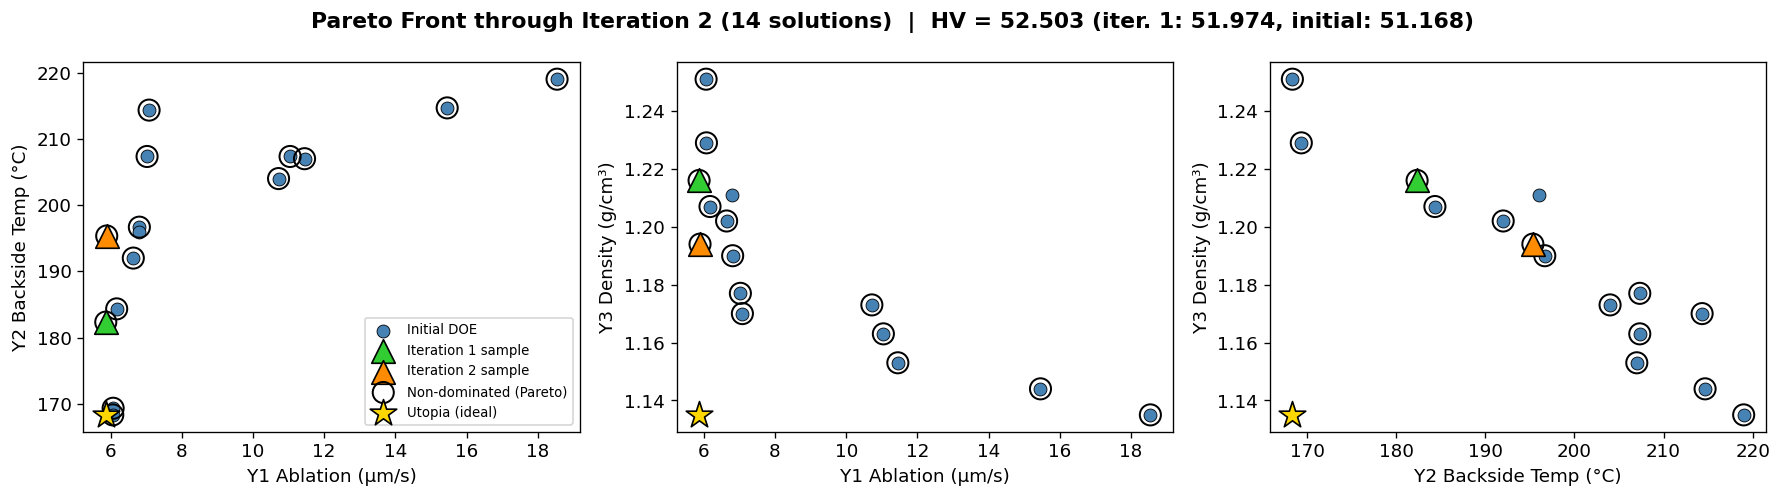

In [24]:
# ── Merge iteration-2 replicates (dataset through iteration 2) ───────────────
df_rep_up2 = replicates_through(2, ITER1_OBSERVED, ITER2_OBSERVED)
df_mean_up2, df_var_up2, Yvar_up2_np, s2_rep_up2 = condition_stats(df_rep_up2)

X_up2 = df_mean_up2[['X1', 'X2']].values.astype(float)
Y_up2 = df_mean_up2[['Y1', 'Y2', 'Y3']].values.astype(float)
Y_up2_neg = -torch.tensor(Y_up2, dtype=DTYPE)
Yvar_up2  = torch.tensor(Yvar_up2_np, dtype=DTYPE)

pm_up2 = is_non_dominated(Y_up2_neg)
hv_up2 = hv_calc_up.compute(Y_up2_neg[pm_up2])

# Email convention: every campaign replicate is its own point
Y_email2  = torch.cat([Y_neg,
                       -torch.tensor(ITER1_OBSERVED[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE),
                       -torch.tensor(ITER2_OBSERVED[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)])
pm_email2 = is_non_dominated(Y_email2)
hv_email2 = hv_calc_up.compute(Y_email2[pm_email2])

is_it1 = campaign_mask(df_mean_up2, 1)
is_it2 = campaign_mask(df_mean_up2, 2)
prev_best2 = df_mean_up2.loc[~is_it2, ['Y1', 'Y2', 'Y3']].min()
new_mean2  = df_mean_up2.loc[is_it2, ['Y1', 'Y2', 'Y3']].iloc[0]
Y_prev     = Y_up2[~is_it2]
dominated_by_new = np.all(new_mean2.values <= Y_prev, axis=1) & np.any(new_mean2.values < Y_prev, axis=1)

print(f"Training set through iter. 2 : {len(df_mean_up2)} conditions")
print(f"Pareto front                 : {int(pm_up2.sum())} solutions")
print(f"Hypervolume (cond. means)    : {hv_init:.4f} → {hv_up:.4f} → {hv_up2:.4f}  "
      f"(+{hv_up2 - hv_up:.4f} this iteration, {(hv_up2/hv_init - 1)*100:+.2f}% vs. initial)")
print(f"Replicates-as-points         : {hv_init:.4f} → {hv_email:.4f} → {hv_email2:.4f} | "
      f"Pareto = {int(pm_email2.sum())}  (email convention)")
print()
print("Insights:")
for col, label in zip(['Y1', 'Y2', 'Y3'], obj_labels):
    tag = 'NEW BEST' if new_mean2[col] < prev_best2[col] else 'not the best'
    print(f"  • {label}: iteration-2 mean {new_mean2[col]:.3f} vs best previous "
          f"{prev_best2[col]:.3f} → {tag}")
print(f"  • Iteration-2 sample is {'ON' if bool(pm_up2[is_it2].all()) else 'NOT on'} the Pareto front; "
      f"it dominates {int(dominated_by_new.sum())} previous condition(s).")
print(f"  • Iteration-1 sample is {'still on' if bool(pm_up2[is_it1].all()) else 'no longer on'} the Pareto front.")
lo_d = df_mean_up2[is_it2 | is_it1 | (df_mean_up2.X1 >= 15)].sort_values('Y3')
print("  • Low-ablation region (X1 ≥ 15) ordered by density — the Y1/Y2 vs Y3 trade-off:")
print(lo_d[['X1', 'X2', 'Y1', 'Y2', 'Y3']].to_string(index=False, float_format='{:.3f}'.format))

plot_objective_pairs(Y_up2, pm_up2.numpy(),
                     [(is_it1, 'limegreen', '^', 200, 'Iteration 1 sample'),
                      (is_it2, 'darkorange', '^', 200, 'Iteration 2 sample')],
                     f'Pareto Front through Iteration 2 ({int(pm_up2.sum())} solutions)  |  '
                     f'HV = {hv_up2:.3f} (iter. 1: {hv_up:.3f}, initial: {hv_init:.3f})')


### Iteration 3 — Next Proposed Sample (trained on data through iteration 2)

The v3 GPs are refitted on the initial DOE + iterations 1–2 (15 conditions) and
qLogEHVI proposes the iteration-3 sample. As before, the prediction table reports
the latent-mean CI and the 95% PI for a single replicate — send both to UIC
(`outputs/v3/iteration3_recommended_sample.xlsx`, written in Section 11). When the
sample is sent, pin the values here as `ITER3_PROPOSED` (like iteration 2) so the
record stays fixed on later re-runs.


Iteration 3 proposed sample : X1 = 20.000, X2 = 2.156
Rounded for fabrication     : X1 = 20.0, X2 = 2.2
qLogEHVI value              : -0.4413   (iteration 2: 0.5311, iteration 1: 0.785)

                Objective  Mean (µ)  σ latent 95% CI (latent mean)  σ pred 95% PI (one replicate)
Y1 — Ablation Rate (µm/s)    5.9180    0.2087     [5.5089, 6.3271]  0.6572       [4.6298, 7.2061]
  Y2 — Backside Temp (°C)  178.4370    1.4420 [175.6108, 181.2632] 10.7036   [157.4578, 199.4161]
     Y3 — Density (g/cm³)    1.2195    0.0006     [1.2183, 1.2207]  0.0012       [1.2172, 1.2218]

At the rounded composition (20.0, 2.2): Y1 5.921 | Y2 178.22 | Y3 1.2200


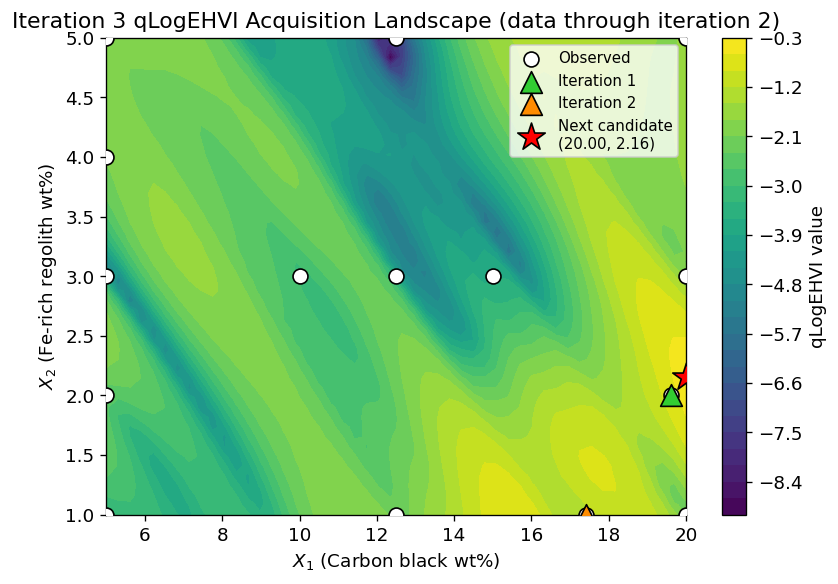

In [25]:
# ── Iteration 3: refit on data through iteration 2, propose next sample ──────
X_up2_01  = torch.tensor(scaler_X.transform(X_up2), dtype=DTYPE)
model_it3 = build_and_fit_models(X_up2_01, Y_up2_neg, Yvar_up2)
model_it3.eval()

torch.manual_seed(42)   # reseed → proposal reproducible independent of earlier cells (same seed as v4)
cand3_01, ehvi3 = get_next_candidates(model_it3, Y_up2_neg, ref_point, bounds, q=1)
cand3_orig = scaler_X.inverse_transform(cand3_01.numpy())
mu3, sd3, sd3_rep = predict_at(model_it3, cand3_orig, s2_rep_up2)

print(f"Iteration 3 proposed sample : X1 = {cand3_orig[0,0]:.3f}, X2 = {cand3_orig[0,1]:.3f}")
print(f"Rounded for fabrication     : X1 = {cand3_orig[0,0]:.1f}, X2 = {cand3_orig[0,1]:.1f}")
print(f"qLogEHVI value              : {ehvi3:.4f}   (iteration 2: {ehvi2:.4f}, iteration 1: 0.785)")
print()
pred3 = pred_interval_table(mu3, sd3, sd3_rep)
print(pred3.to_string(index=False))

# Prediction at the rounded (fabricated) composition, for reference
mu3r, sd3r, sd3r_rep = predict_at(model_it3, np.round(cand3_orig, 1), s2_rep_up2)
print(f"\nAt the rounded composition ({cand3_orig[0,0]:.1f}, {cand3_orig[0,1]:.1f}): "
      f"Y1 {mu3r[0]:.3f} | Y2 {mu3r[1]:.2f} | Y3 {mu3r[2]:.4f}")

acq_map3 = acq_landscape(model_it3, Y_up2_neg)
plot_acq_landscape(acq_map3, X_up2, cand3_orig,
                   'Iteration 3 qLogEHVI Acquisition Landscape (data through iteration 2)',
                   f'Next candidate\n({cand3_orig[0,0]:.2f}, {cand3_orig[0,1]:.2f})',
                   marks=[(ITERATION_SAMPLES[1][0], 'limegreen', 'Iteration 1'),
                          (ITERATION_SAMPLES[2][0], 'darkorange', 'Iteration 2')])


#### Iteration 3 — Observed results: *pending*

When UIC returns the iteration-3 results: (1) pin the sent proposal as
`ITER3_PROPOSED` in the cell above, (2) add an `ITER3_OBSERVED` DataFrame and call
`compare_observed(ITER3_OBSERVED, mu3, sd3, sd3_rep, it=3)`, (3) append the
replicate rows to `data/ablation_data.xlsx` and add the condition to
`ITERATION_SAMPLES` in Section 1 (`replicates_through` prevents double-counting
either way), then re-run the notebook.


## 11. Export Iteration Outputs

Writes per-iteration proposals, predictions, and observed results to
`../outputs/v3/bo_iterations.xlsx` (sheets: summary, predictions, observed,
info), and the one-sheet recommendation file for UIC
(`../outputs/v3/iteration3_recommended_sample.xlsx`, same layout as the
iteration-2 file sent on Aug 12, 2026). Regenerated on every full run, so the file always reflects the current
spreadsheet and model.


In [26]:
# ── Export BO-iteration outputs → ../outputs/v3/bo_iterations.xlsx ───────────
import os
OUT_DIR = '../outputs/v3'
os.makedirs(OUT_DIR, exist_ok=True)
obj_short = ['Y1 ablation (µm/s)', 'Y2 backside temp (°C)', 'Y3 density (g/cm³)']

# Iterations 1–2 are historical campaign records (pinned proposals, tested);
# iteration 3 carries this run's Section-10 proposal.
summary = pd.DataFrame([
    {'iteration': 1, 'proposed_X1': 19.58, 'proposed_X2': 1.99,
     'fabricated_X1': 19.6, 'fabricated_X2': 2.0, 'qLogEHVI': 0.785,
     'status': 'tested (Jul 20, 2026)', 'note': 'proposed Jul 10, 2026 (v1 model)'},
    {'iteration': 2, 'proposed_X1': float(ITER2_PROPOSED[0, 0]), 'proposed_X2': float(ITER2_PROPOSED[0, 1]),
     'fabricated_X1': 17.4, 'fabricated_X2': 1.0, 'qLogEHVI': ITER2_EHVI,
     'status': 'tested (Aug 26, 2026)', 'note': 'proposed Aug 12, 2026 (v3 model, Section 10)'},
    {'iteration': 3, 'proposed_X1': round(float(cand3_orig[0, 0]), 3),
     'proposed_X2': round(float(cand3_orig[0, 1]), 3),
     'fabricated_X1': round(float(cand3_orig[0, 0]), 1),
     'fabricated_X2': round(float(cand3_orig[0, 1]), 1),
     'qLogEHVI': round(float(ehvi3), 4), 'status': 'pending',
     'note': 'proposed by v3 model, Section 10 (this run)'},
])

def pred_rows(it, m, s, sp):
    return [{'iteration': it, 'objective': obj_short[k],
             'mean': round(float(m[k]), 4), 'sd_latent': round(float(s[k]), 4),
             'ci95_low': round(float(m[k] - 1.96*s[k]), 4),
             'ci95_high': round(float(m[k] + 1.96*s[k]), 4),
             'sd_pred': round(float(sp[k]), 4),
             'pi95_low': round(float(m[k] - 1.96*sp[k]), 4),
             'pi95_high': round(float(m[k] + 1.96*sp[k]), 4)} for k in range(3)]

predictions = pd.DataFrame(pred_rows(1, mu, sd, sd_rep) + pred_rows(2, mu2, sd2, sd2_rep)
                           + pred_rows(3, mu3, sd3, sd3_rep))

observed = pd.concat([ITER1_OBSERVED.assign(iteration=1, replicate=[1, 2, 3]),
                      ITER2_OBSERVED.assign(iteration=2, replicate=[1, 2, 3])], ignore_index=True)
observed = observed[['iteration', 'replicate', 'X1', 'X2', 'Y1', 'Y2', 'Y3']]

info = pd.DataFrame({
    'field': ['version', 'model', 'source notebook', 'intervals', 'observed data source'],
    'value': ['v3', 'fixed-noise SingleTaskGP per objective (train_Yvar = s²/n from replicates)', 'mobo_analysis_v3.ipynb',
              'ci95 = latent-mean CI; pi95 = 95% prediction interval for one replicate (latent + pooled s̄²)',
              'iter 1: resources/email.pdf (UIC, Jul 20, 2026); iter 2: data/17.4_1_(08_26).xlsx (UIC, Aug 26, 2026)'],
})

path = os.path.join(OUT_DIR, 'bo_iterations.xlsx')
with pd.ExcelWriter(path) as xl:
    summary.to_excel(xl, sheet_name='summary', index=False)
    predictions.to_excel(xl, sheet_name='predictions', index=False)
    observed.to_excel(xl, sheet_name='observed', index=False)
    info.to_excel(xl, sheet_name='info', index=False)
print(f'Wrote {path}')
print(summary.to_string(index=False))


Wrote ../outputs/v3/bo_iterations.xlsx
 iteration  proposed_X1  proposed_X2  fabricated_X1  fabricated_X2  qLogEHVI                status                                         note
         1       19.580        1.990           19.6            2.0    0.7850 tested (Jul 20, 2026)             proposed Jul 10, 2026 (v1 model)
         2       17.352        1.000           17.4            1.0    0.5311 tested (Aug 26, 2026) proposed Aug 12, 2026 (v3 model, Section 10)
         3       20.000        2.156           20.0            2.2   -0.4413               pending  proposed by v3 model, Section 10 (this run)


In [27]:
# ── One-sheet recommendation file for UIC (same layout as iteration 2's) ─────
from openpyxl import Workbook
from openpyxl.styles import Font

I369_WT = 2.0                       # fixed additive; resin fills the remainder
x1_fab, x2_fab = round(float(cand3_orig[0, 0]), 1), round(float(cand3_orig[0, 1]), 1)
rec_rows = [
    ('Recommended sample (iteration 3)', None, None),
    ('Component', 'wt%', None),
    ('Carbon black', x1_fab, None),
    ('Fe-rich regolith', x2_fab, None),
    ('I-369', I369_WT, None),
    ('Resin', round(100 - x1_fab - x2_fab - I369_WT, 1), None),
    (None, None, None),
    ('Predicted values', None, None),
    ('Objective', 'Predicted mean', 'Expected range per replicate (95%)'),
    ('Linear ablative rate (µm/s)', round(float(mu3[0]), 2), f'{mu3[0]-1.96*sd3_rep[0]:.1f} – {mu3[0]+1.96*sd3_rep[0]:.1f}'),
    ('Backside temp. (°C)',         round(float(mu3[1]), 1), f'{mu3[1]-1.96*sd3_rep[1]:.1f} – {mu3[1]+1.96*sd3_rep[1]:.1f}'),
    ('Density (g/cm³)',             round(float(mu3[2]), 4), f'{mu3[2]-1.96*sd3_rep[2]:.4f} – {mu3[2]+1.96*sd3_rep[2]:.4f}'),
]
wb_rec = Workbook(); ws_rec = wb_rec.active; ws_rec.title = 'recommendation'
for r in rec_rows:
    ws_rec.append(list(r))
for coord in ('A1', 'A2', 'B2', 'A8', 'A9', 'B9', 'C9'):
    ws_rec[coord].font = Font(bold=True)
for col, w in zip('ABC', (28, 15, 34)):
    ws_rec.column_dimensions[col].width = w
rec_path = os.path.join(OUT_DIR, 'iteration3_recommended_sample.xlsx')
wb_rec.save(rec_path)
print(f'Wrote {rec_path}')
print(pd.DataFrame(rec_rows[2:6], columns=['Component', 'wt%', '']).iloc[:, :2].to_string(index=False))


Wrote ../outputs/v3/iteration3_recommended_sample.xlsx
       Component  wt%
    Carbon black 20.0
Fe-rich regolith  2.2
           I-369  2.0
           Resin 75.8


## 12. Iteration Gain Analysis

Tracks what each BO iteration adds on top of the initial DOE:

- **`../outputs/v3/ablation_data_by_iteration.xlsx`** — the full replicate dataset
  with an `Iteration` column and per-iteration row highlighting (0 = initial DOE,
  1 = July 2026 sample, 2 = August 2026 sample, …). `ITERATION_SAMPLES` (Section 1)
  is the single place to extend when a new iteration's data arrives.
- A **gain table**: best condition-mean so far per output, plus hypervolume by
  iteration in both conventions (condition means / email convention).
- **Three visualization variants** of output-vs-iteration gain: V1 best-so-far
  convergence, V2 replicate distributions per iteration, V3 Pareto-level gains
  (hypervolume growth, front composition, utopia-gap closing).


In [28]:
# ── Iteration labels + highlighted Excel export ──────────────────────────────
# ITERATION_SAMPLES is defined in Section 1; the observed DataFrames cover the case
# where a result has been recorded in Section 10 but not yet appended to the spreadsheet.
df_all = replicates_through(max(ITERATION_SAMPLES), ITER1_OBSERVED, ITER2_OBSERVED)
df_all.insert(0, 'Iteration', [iteration_of(r.X1, r.X2) for r in df_all.itertuples()])

EXPORT_COLS = {'X1': 'Carbon black wt%', 'X2': 'Fe-rich regolith wt%',
               'Y1': 'Linear ablative rate (µm/s)', 'Y2': 'Backside temp. (°C)',
               'Y3': 'Density (g/cm³)'}
excel_path = '../outputs/v3/ablation_data_by_iteration.xlsx'
df_all.rename(columns=EXPORT_COLS).to_excel(excel_path, index=False)

# per-iteration row highlighting
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
ITER_FILLS = {1: 'FFF2CC', 2: 'D9EAD3', 3: 'CFE2F3', 4: 'F4CCCC'}
wb = load_workbook(excel_path); ws = wb.active
for c in ws[1]:
    c.font = Font(bold=True)
for row in ws.iter_rows(min_row=2):
    fill = ITER_FILLS.get(row[0].value)
    if fill:
        for c in row:
            c.fill = PatternFill('solid', fgColor=fill)
for col_cells in ws.columns:
    ws.column_dimensions[col_cells[0].column_letter].width = max(
        len(str(c.value)) for c in col_cells if c.value is not None) + 2
wb.save(excel_path)

print(f"Wrote {excel_path} ({len(df_all)} rows, "
      f"{int((df_all.Iteration > 0).sum())} highlighted BO rows)")
print(df_all.groupby('Iteration').size().rename('replicates').to_string())


Wrote ../outputs/v3/ablation_data_by_iteration.xlsx (45 rows, 6 highlighted BO rows)
Iteration
0    39
1     3
2     3


In [29]:
# ── Per-output & Pareto gains by iteration ───────────────────────────────────
iterations   = sorted(df_all['Iteration'].unique())
mean_by_cond = df_all.groupby(['Iteration', 'X1', 'X2'])[['Y1', 'Y2', 'Y3']].mean().reset_index()

# reference point from the initial DOE only (stable as iterations accumulate)
Y0m = -torch.tensor(mean_by_cond.loc[mean_by_cond.Iteration == 0,
                                     ['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)
ref_g  = Y0m.min(0).values - 0.10 * (Y0m.max(0).values - Y0m.min(0).values)
hv_g   = Hypervolume(ref_point=ref_g)

gain_rows, hv_rows = [], []
for t in iterations:
    upto = mean_by_cond[mean_by_cond.Iteration <= t]
    for col, label in zip(['Y1', 'Y2', 'Y3'], obj_labels):
        best0, best = mean_by_cond.loc[mean_by_cond.Iteration == 0, col].min(), upto[col].min()
        gain_rows.append({'Iteration': t, 'Output': label,
                          'Best mean so far': round(best, 4),
                          'Δ vs DOE': round(best - best0, 4),
                          'Reduction %': round(100 * (best0 - best) / best0, 2)})
    Ym = -torch.tensor(upto[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)
    reps = df_all[(df_all.Iteration > 0) & (df_all.Iteration <= t)]
    Yr = torch.cat([Y0m, -torch.tensor(reps[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)])
    hv_rows.append({'Iteration': t,
                    'HV (cond. means)': round(hv_g.compute(Ym[is_non_dominated(Ym)]), 4),
                    'HV (email conv.)': round(hv_g.compute(Yr[is_non_dominated(Yr)]), 4),
                    'Pareto size (means)': int(is_non_dominated(Ym).sum())})

print('Best-so-far per output (condition means):')
print(pd.DataFrame(gain_rows).to_string(index=False))
hv_table = pd.DataFrame(hv_rows)
hv_table['ΔHV means %'] = (100 * (hv_table['HV (cond. means)'] / hv_table.loc[0, 'HV (cond. means)'] - 1)).round(2)
hv_table['ΔHV email %'] = (100 * (hv_table['HV (email conv.)'] / hv_table.loc[0, 'HV (email conv.)'] - 1)).round(2)
print()
print('Hypervolume by iteration:')
print(hv_table.to_string(index=False))


Best-so-far per output (condition means):
 Iteration                Output  Best mean so far  Δ vs DOE  Reduction %
         0    Y1 Ablation (µm/s)            6.0633    0.0000         0.00
         0 Y2 Backside Temp (°C)          168.3333    0.0000         0.00
         0    Y3 Density (g/cm³)            1.1350    0.0000         0.00
         1    Y1 Ablation (µm/s)            5.8667   -0.1967         3.24
         1 Y2 Backside Temp (°C)          168.3333    0.0000         0.00
         1    Y3 Density (g/cm³)            1.1350    0.0000         0.00
         2    Y1 Ablation (µm/s)            5.8667   -0.1967         3.24
         2 Y2 Backside Temp (°C)          168.3333    0.0000         0.00
         2    Y3 Density (g/cm³)            1.1350    0.0000         0.00

Hypervolume by iteration:
 Iteration  HV (cond. means)  HV (email conv.)  Pareto size (means)  ΔHV means %  ΔHV email %
         0           51.1684           51.1684                   12         0.00         0.00
   

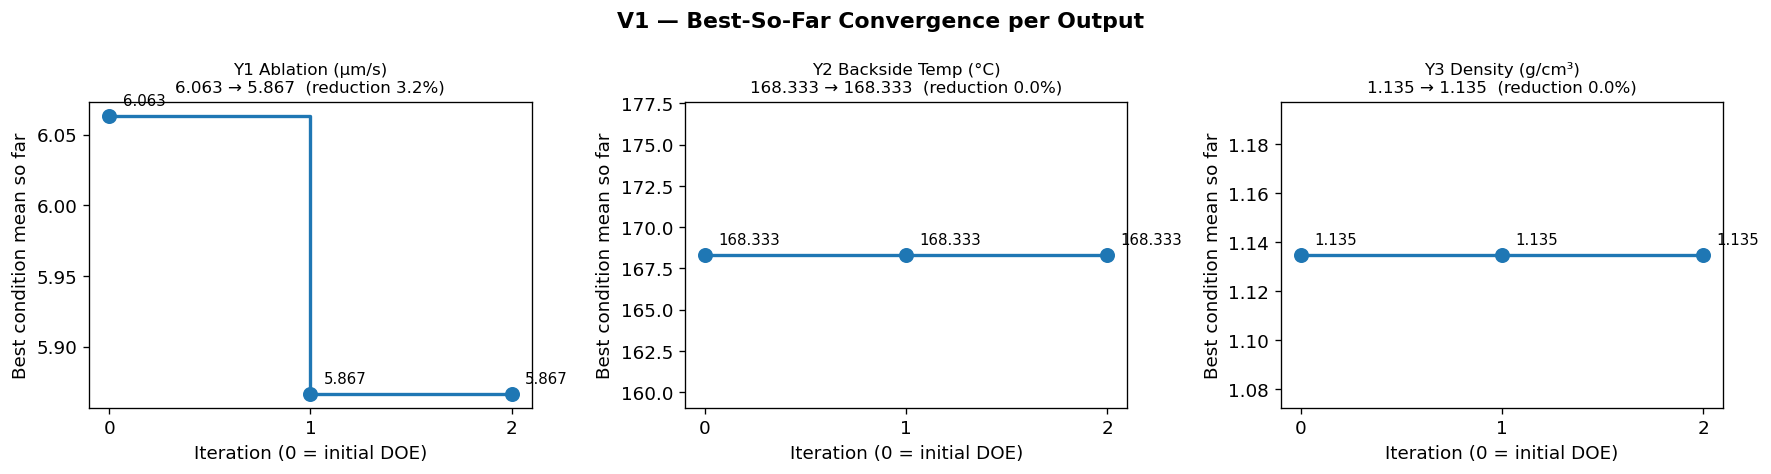

In [30]:
# ── Gain viz V1: best-so-far convergence per output ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['Y1', 'Y2', 'Y3'], obj_labels):
    best = [mean_by_cond.loc[mean_by_cond.Iteration <= t, col].min() for t in iterations]
    ax.step(iterations, best, where='post', lw=2, color='tab:blue', marker='o', ms=8, zorder=3)
    for t, b in zip(iterations, best):
        ax.annotate(f'{b:.3f}', (t, b), textcoords='offset points', xytext=(8, 6), fontsize=9)
    red = 100 * (best[0] - best[-1]) / best[0]
    ax.set_title(f'{label}\n{best[0]:.3f} → {best[-1]:.3f}  (reduction {red:.1f}%)', fontsize=10)
    ax.set_xlabel('Iteration (0 = initial DOE)')
    ax.set_ylabel('Best condition mean so far')
    ax.set_xticks(iterations)
plt.suptitle('V1 — Best-So-Far Convergence per Output', fontweight='bold')
plt.tight_layout(); plt.show()


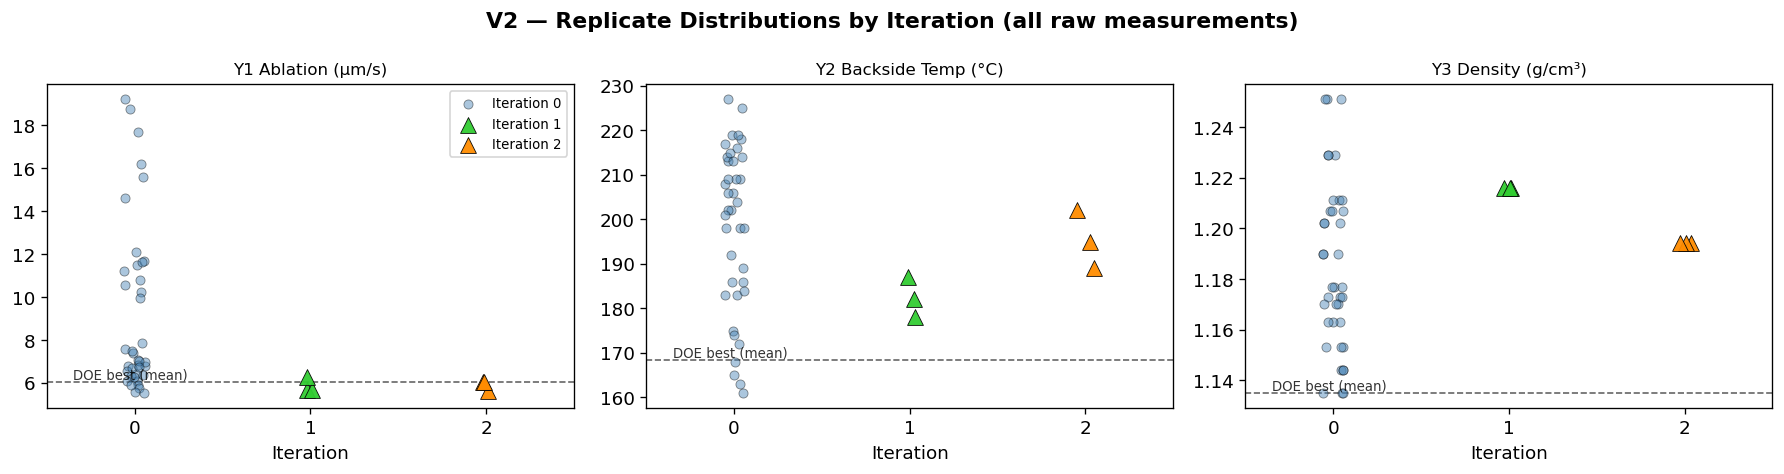

In [31]:
# ── Gain viz V2: replicate distributions per iteration ───────────────────────
it_colors = {0: 'steelblue', 1: 'limegreen', 2: 'darkorange', 3: 'seagreen'}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['Y1', 'Y2', 'Y3'], obj_labels):
    for t in iterations:
        vals = df_all.loc[df_all.Iteration == t, col].values
        x = t + rng.uniform(-0.06, 0.06, len(vals))
        ax.scatter(x, vals, s=90 if t else 30, alpha=0.95 if t else 0.45,
                   c=it_colors.get(t, 'gray'), edgecolors='k', lw=0.5,
                   marker='^' if t else 'o', zorder=3 + t,
                   label=(f'Iteration {t}' if ax is axes[0] else None))
    best0 = mean_by_cond.loc[mean_by_cond.Iteration == 0, col].min()
    ax.axhline(best0, color='k', ls='--', lw=1, alpha=0.6)
    ax.annotate('DOE best (mean)', (iterations[0] - 0.35, best0),
                fontsize=8, va='bottom', alpha=0.8)
    ax.set_xticks(iterations); ax.set_xlim(iterations[0] - 0.5, iterations[-1] + 0.5)
    ax.set_xlabel('Iteration'); ax.set_title(label, fontsize=10)
axes[0].legend(fontsize=8)
plt.suptitle('V2 — Replicate Distributions by Iteration (all raw measurements)',
             fontweight='bold')
plt.tight_layout(); plt.show()


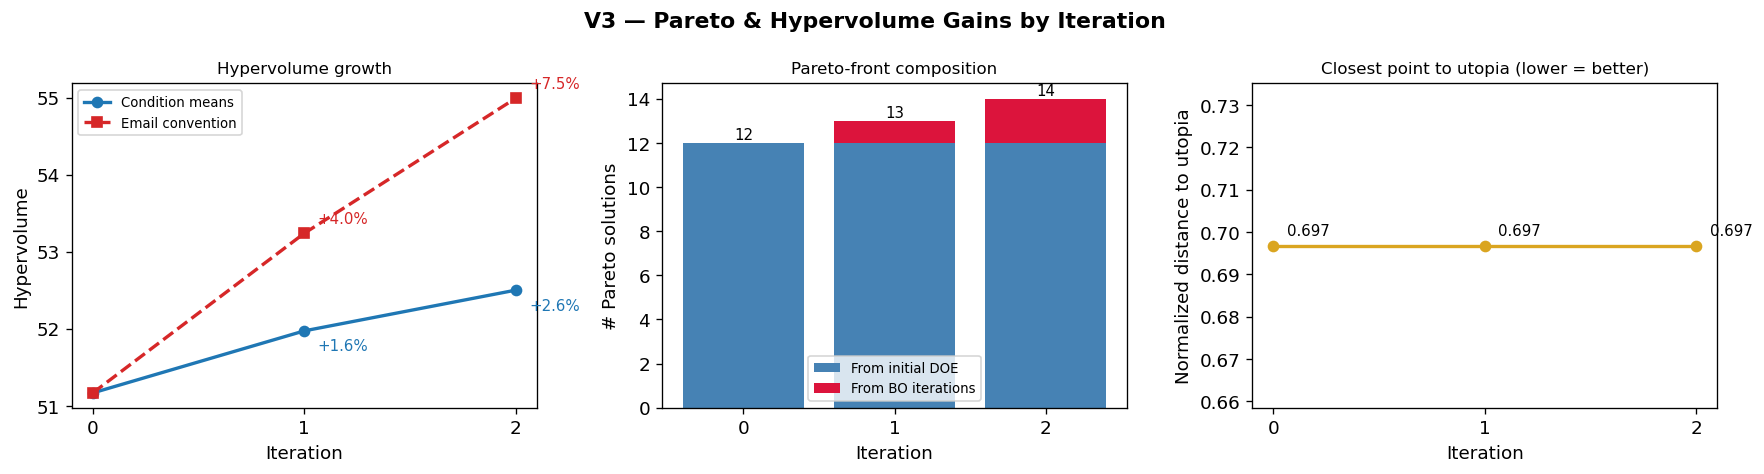

In [32]:
# ── Gain viz V3: Pareto-level gains ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) hypervolume growth
axes[0].plot(hv_table['Iteration'], hv_table['HV (cond. means)'], 'o-', lw=2,
             color='tab:blue', label='Condition means')
axes[0].plot(hv_table['Iteration'], hv_table['HV (email conv.)'], 's--', lw=2,
             color='tab:red', label='Email convention')
for _, r in hv_table.iterrows():
    axes[0].annotate(f"+{r['ΔHV means %']:.1f}%" if r['Iteration'] else '',
                     (r['Iteration'], r['HV (cond. means)']),
                     textcoords='offset points', xytext=(8, -12), fontsize=9, color='tab:blue')
    axes[0].annotate(f"+{r['ΔHV email %']:.1f}%" if r['Iteration'] else '',
                     (r['Iteration'], r['HV (email conv.)']),
                     textcoords='offset points', xytext=(8, 6), fontsize=9, color='tab:red')
axes[0].set_xticks(iterations); axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Hypervolume'); axes[0].set_title('Hypervolume growth', fontsize=10)
axes[0].legend(fontsize=8)

# (b) Pareto-front composition: who contributes the front at each stage
bars0, barsk = [], []
for t in iterations:
    upto = mean_by_cond[mean_by_cond.Iteration <= t].reset_index(drop=True)
    pm = is_non_dominated(-torch.tensor(upto[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)).numpy()
    origin = upto.loc[pm, 'Iteration']
    bars0.append(int((origin == 0).sum())); barsk.append(int((origin > 0).sum()))
axes[1].bar(iterations, bars0, color='steelblue', label='From initial DOE')
axes[1].bar(iterations, barsk, bottom=bars0, color='crimson', label='From BO iterations')
for t, (a, b) in enumerate(zip(bars0, barsk)):
    axes[1].text(iterations[t], a + b + 0.15, f'{a + b}', ha='center', fontsize=9)
axes[1].set_xticks(iterations); axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('# Pareto solutions'); axes[1].set_title('Pareto-front composition', fontsize=10)
axes[1].legend(fontsize=8)

# (c) utopia-gap closing: normalized distance of the closest point to the ideal
lo = mean_by_cond[['Y1', 'Y2', 'Y3']].min(); span = mean_by_cond[['Y1', 'Y2', 'Y3']].max() - lo
gaps = []
for t in iterations:
    upto = mean_by_cond[mean_by_cond.Iteration <= t]
    norm = (upto[['Y1', 'Y2', 'Y3']] - lo) / span
    gaps.append(float(np.sqrt((norm ** 2).sum(axis=1)).min()))
axes[2].plot(iterations, gaps, 'o-', lw=2, color='goldenrod')
for t, g in zip(iterations, gaps):
    axes[2].annotate(f'{g:.3f}', (t, g), textcoords='offset points', xytext=(8, 6), fontsize=9)
axes[2].set_xticks(iterations); axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Normalized distance to utopia')
axes[2].set_title('Closest point to utopia (lower = better)', fontsize=10)

plt.suptitle('V3 — Pareto & Hypervolume Gains by Iteration', fontweight='bold')
plt.tight_layout(); plt.show()


#### GP response surfaces with campaign points

Posterior mean and latent σ of the **v3 (replicate-noise) GPs fitted to the data
through iteration 2**, with the tested campaign samples (triangles: iteration 1
green, iteration 2 orange) and the proposed iteration-3 sample (gold star) marked
against the initial DOE (white dots).


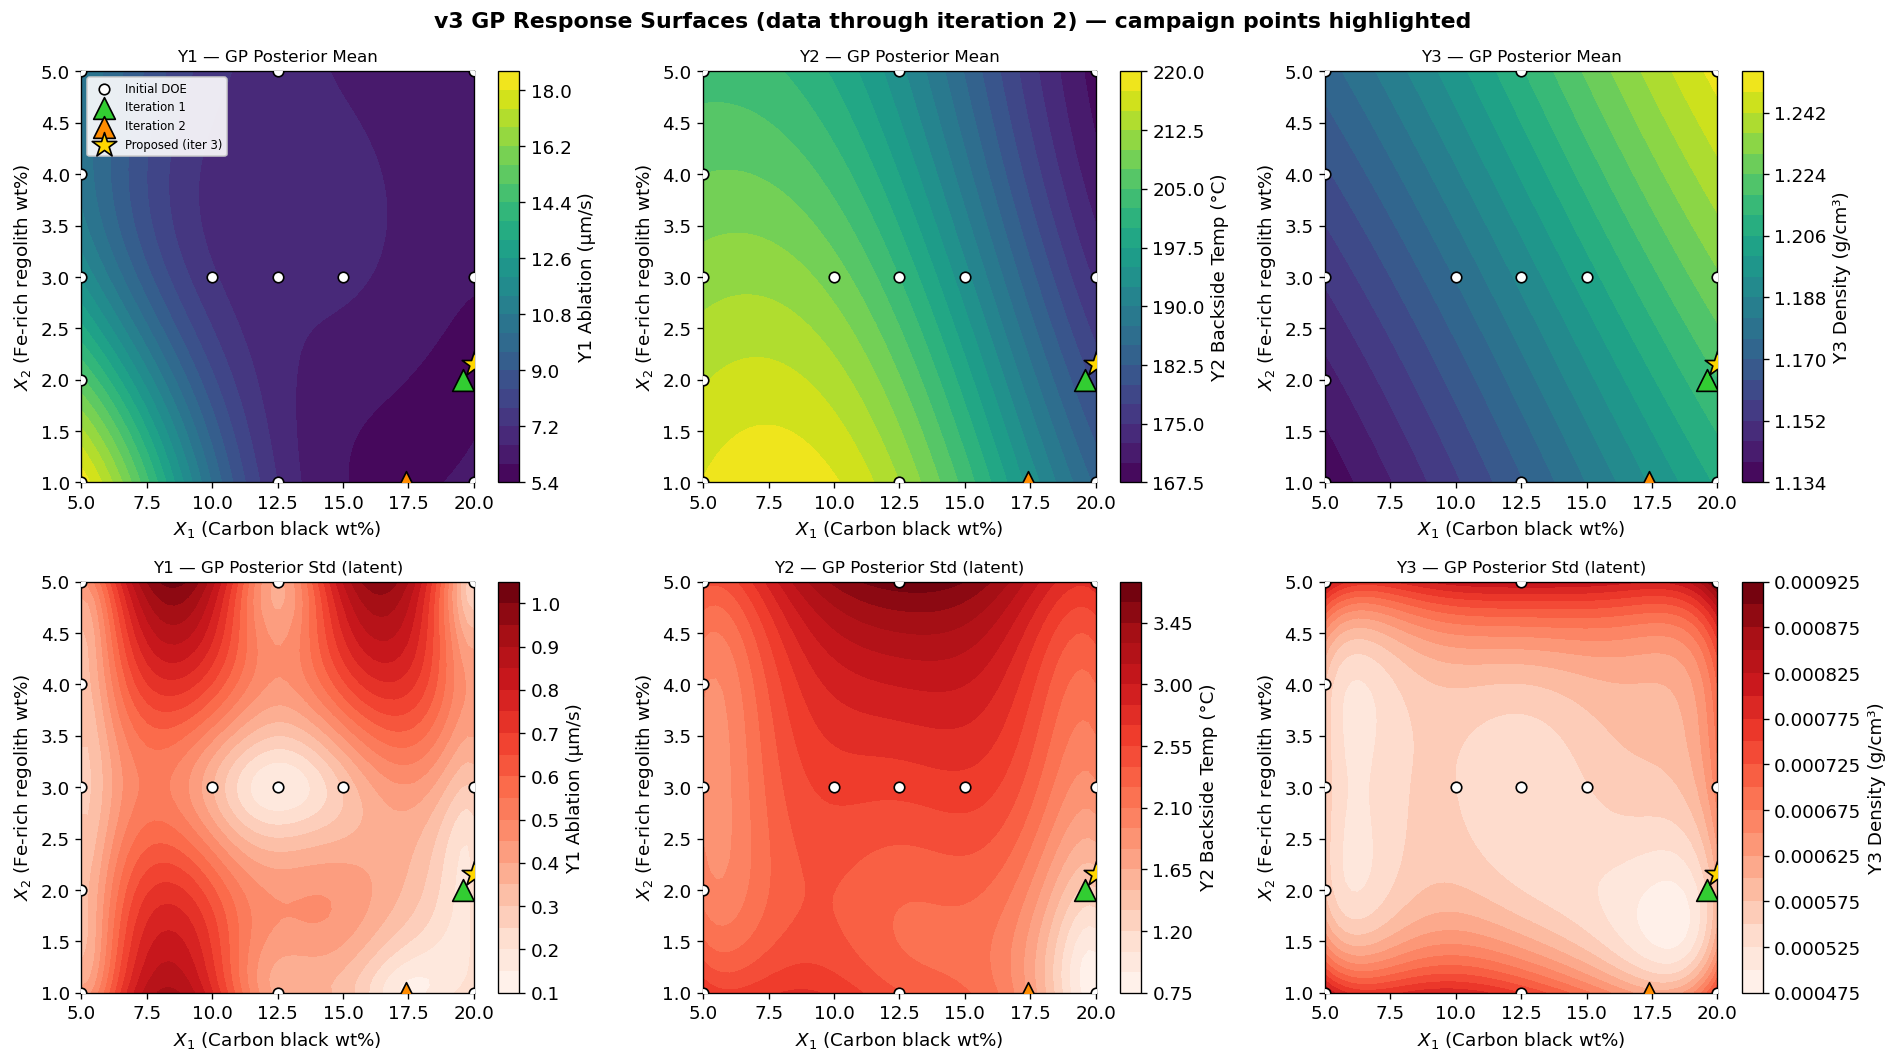

In [33]:
# ── v3 GP response surfaces with campaign points ─────────────────────────────
PROPOSED_NEXT = (float(cand3_orig[0, 0]), float(cand3_orig[0, 1]))   # iteration-3 proposal (Section 10)
NEXT_ITER     = max(ITERATION_SAMPLES) + 1

torch.manual_seed(42)
X_rs_01 = torch.tensor(scaler_X.transform(X_up2), dtype=DTYPE)
model_rs = build_and_fit_models(X_rs_01, Y_up2_neg, Yvar_up2)
model_rs.eval()

n_g = 60
g1, g2 = np.linspace(5, 20, n_g), np.linspace(1, 5, n_g)
G1, G2 = np.meshgrid(g1, g2)
Xg = torch.tensor(scaler_X.transform(np.column_stack([G1.ravel(), G2.ravel()])), dtype=DTYPE)
with torch.no_grad():
    post_rs = model_rs.posterior(Xg)
    mu_g = -post_rs.mean.numpy()
    sd_g = post_rs.variance.sqrt().numpy()

init_mask = campaign_mask(df_mean_up2, 0)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for k, label in enumerate(obj_labels):
    for row, (Z, cmap, ttl) in enumerate([(mu_g[:, k], 'viridis', 'Posterior Mean'),
                                          (sd_g[:, k], 'Reds', 'Posterior Std (latent)')]):
        ax = axes[row, k]
        first = (row == 0 and k == 0)
        cp = ax.contourf(G1, G2, Z.reshape(G1.shape), levels=20, cmap=cmap)
        plt.colorbar(cp, ax=ax, label=label)
        ax.scatter(X_up2[init_mask, 0], X_up2[init_mask, 1], c='white', edgecolors='k',
                   s=40, zorder=5, label='Initial DOE' if first else None)
        for it, conds in ITERATION_SAMPLES.items():
            for x1, x2 in conds:
                ax.scatter(x1, x2, c=it_colors.get(it, 'gray'), marker='^', s=170,
                           edgecolors='k', zorder=6, label=f'Iteration {it}' if first else None)
        ax.scatter(*PROPOSED_NEXT, c='gold', marker='*', s=240, edgecolors='k', zorder=6,
                   label=f'Proposed (iter {NEXT_ITER})' if first else None)
        if first:
            ax.legend(fontsize=7, loc='upper left', framealpha=0.9)
        ax.set_xlabel('$X_1$ (Carbon black wt%)')
        ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
        ax.set_title(f"{['Y1', 'Y2', 'Y3'][k]} — GP {ttl}", fontsize=10)
plt.suptitle('v3 GP Response Surfaces (data through iteration 2) — campaign points highlighted',
             fontweight='bold')
plt.tight_layout(); plt.show()
